## The Environment

In [1]:
# Core imports for data handling, visualization, preprocessing pipelines, model training, and anomaly detection workflow.

import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")

plt.style.use("ggplot")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)


In [2]:
!pip install pvlib
import pvlib

from sklearn.preprocessing import StandardScaler


In [3]:
# Install dependencies as needed: pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter


In [4]:
import seaborn as sns

In [5]:
from sklearn.preprocessing import MinMaxScaler



---



## Data Ingestion

In [6]:
# The dataset files are located at this path:
DATASET_PATH = '/kaggle/input/pvdaq-systems-2105-and-2107'

# List the files available in the dataset to identify the correct filename.
print(f"Files available in the dataset '{DATASET_PATH}':")
if os.path.exists(DATASET_PATH):
    for file_name in os.listdir(DATASET_PATH):
        print(f"- {file_name}")
else:
    print("Dataset path not found. Please ensure the Kaggle dataset is properly attached.")

# Set the path to the file you'd like to load.
file_path = "2107_meter_15m_data.csv"

# Load the latest version.
# Note: kagglehub.load_dataset() is deprecated. Consider using kagglehub.dataset_load() in the future.
# Uncomment the following lines and update 'file_path' with an actual filename to load the data.
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "aliassadbeiki/pvdaq-systems-2105-and-2107",
  file_path,
  # Provide any additional arguments like sql_query or pandas_kwargs. See the documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records of the table...:", df.head())


"""
Put the below in a script to be executed by the user.
Put it in a try-except statement...:
- get the data via Kaggle API.


try:
-> read the /content/ folder and check if the dataset exist.
--- if not, read the Kaggle API and retrieve the dataset...1 file at a time:
----- 2107.
----- -- 2107_meter_15m_data.csv
----- -- 2107_irradiance_data.csv
----- -- 2107_environment_data.csv
----- -- 2107_system_metadata.json
don't touch the JSON file.


beginning of 2020 to the end of 2021...:
do the following to the other 3 CSV 1 at a time...:
Filter out to a specific time period...: beginning of 2020 to the end of 2021.
Make it to be 15 minutes interval between every row.
Show summary statistics for the resampled table or DataFrame...

Do something about the null or missing values in the data.

Now, export it to the /content/ folder.
-> The data, beginning of 2020 to end of 2021 should be 3 separate files, each with the following name:
--- 2107_meter_15m_data.csv to 2107_envdatatr.csv
--- 2107_irradiance_data.csv to 2107_irrdatatr.csv
--- 2107_environment_data.csv to 2107_envdatatr.csv


beginning of 2022 to the end of 2022...:
do the following to the other 3 CSV 1 at a time...:
Filter out to a specific time period...: beginning of 2022 to the end of 2022.
Make it to be 15 minutes interval between every row.
Show summary statistics for the resampled table or DataFrame...

Do something about the null or missing values in the data.

Merge those 3 into 1 single CSV file: 2107_mergeddatates.csv and export it to the /content/ folder.

"""

Files available in the dataset '/kaggle/input/pvdaq-systems-2105-and-2107':
- 2107_meter_15m_data.csv
- 2105_irradiance_data.csv
- 2105_inv11_data.csv
- 2105_environment_1_data.csv
- 2105_inv02_data.csv
- 2105_inv08_data.csv
- 2107_irradiance_data.csv
- 2105_inv01_data.csv
- 2105_system_metadata_v1.json
- 2105_inv03_data.csv
- 2107_environment_data.csv
- 2107_system_metadata.json
- 2105_inv07_data.csv
- 2105_inv06_data.csv
- 2105_inv10_data.csv
- 2105_inv09_data.csv
- 2105_environment_2_data.csv
- 2105_inv05_data.csv
- 2107_electrical_data_v1.csv
- 2105_meter_data.csv
- 2105_inv04_data.csv
Using Colab cache for faster access to the 'pvdaq-systems-2105-and-2107' dataset.
First 5 records of the table...:            measured_on  meter_revenue_grade_ac_output_meter_149578
0  2017-01-01 00:15:00                                         0.0
1  2017-01-01 00:30:00                                         0.0
2  2017-01-01 00:45:00                                         0.0
3  2017-01-01 01:00:

"\nPut the below in a script to be executed by the user.\nPut it in a try-except statement...:\n- get the data via Kaggle API.\n\n\ntry:\n-> read the /content/ folder and check if the dataset exist.\n--- if not, read the Kaggle API and retrieve the dataset...1 file at a time:\n----- 2107.\n----- -- 2107_meter_15m_data.csv\n----- -- 2107_irradiance_data.csv\n----- -- 2107_environment_data.csv\n----- -- 2107_system_metadata.json\ndon't touch the JSON file.\n\n\nbeginning of 2020 to the end of 2021...:\ndo the following to the other 3 CSV 1 at a time...:\nFilter out to a specific time period...: beginning of 2020 to the end of 2021.\nMake it to be 15 minutes interval between every row.\nShow summary statistics for the resampled table or DataFrame...\n\nDo something about the null or missing values in the data.\n\nNow, export it to the /content/ folder.\n-> The data, beginning of 2020 to end of 2021 should be 3 separate files, each with the following name:\n--- 2107_meter_15m_data.csv to 2



---



## The Data Load

In [7]:
# --- 1. Initial Data Loading and Merging for Training Data (df_2107) ---
dataframes = {}
file_paths = [
    "/content/2107_meterdatatr.csv",
    "/content/2107_irrdatatr.csv",
    "/content/2107_envdatatr.csv"
]

for file_path in file_paths:
    try:
        df_name = os.path.basename(file_path).split('.')[0]
        df_temp = pd.read_csv(file_path)
        if 'Unnamed: 0' in df_temp.columns:
            df_temp = df_temp.rename(columns={'Unnamed: 0': 'measured_on'})
        dataframes[df_name] = df_temp
        print(f"Successfully loaded and processed {file_path}")
    except FileNotFoundError:
        print(f"Error: File not found at {file_path}")
    except Exception as e:
        print(f"Error loading {file_path}: {e}")

df_2107 = pd.DataFrame()
base_df_name = None

if '2107_meterdatatr' in dataframes and 'measured_on' in dataframes['2107_meterdatatr'].columns:
    df_2107 = dataframes['2107_meterdatatr'].copy()
    base_df_name = '2107_meterdatatr'
    print(f"Initialized df_2107 with {base_df_name}.")
elif '2107_irrdatatr' in dataframes and 'measured_on' in dataframes['2107_irrdatatr'].columns:
    df_2107 = dataframes['2107_irrdatatr'].copy()
    base_df_name = '2107_irrdatatr'
    print(f"Initialized df_2107 with {base_df_name}.")
else:
    for name, df in dataframes.items():
        if 'measured_on' in df.columns:
            df_2107 = df.copy()
            base_df_name = name
            print(f"Initialized df_2107 with {base_df_name}.")
            break

if df_2107.empty:
    print("Warning: No suitable base dataframe with 'measured_on' column found, starting with empty DataFrame.")
else:
    for df_name, df_to_merge in dataframes.items():
        if df_name != base_df_name:
            if 'measured_on' in df_to_merge.columns:
                df_2107 = pd.merge(df_2107, df_to_merge, on='measured_on', how='outer')
                print(f"Merged {df_name}")
            else:
                print(f"Skipping merge for {df_name}: 'measured_on' column missing in this dataframe.")

if 'measured_on' in df_2107.columns:
    df_2107['measured_on'] = pd.to_datetime(df_2107['measured_on'])
    df_2107 = df_2107.set_index('measured_on')
    print("Converted 'measured_on' to datetime index.")
else:
    print("Warning: 'measured_on' column not found, cannot set as datetime index.")

df_2107 = df_2107.sort_index()
print("Data sorted chronologically by index.")

missing_values = df_2107.isnull().sum()
print("\nMissing values after initial merging and sorting (df_2107):\n")
print(missing_values[missing_values > 0])
print("\nFirst 5 rows of df_2107 after initial loading:\n")
display(df_2107.head())

# --- 2. Define Column Mapping and Descriptions ---
column_mapping = {
    'meter_revenue_grade_ac_output_meter_149578': 'ac_output_kw',
    'poa_irradiance_o_149574': 'poa_irradiance',
    'ambient_temperature_o_149575': 'ambient_temp_f',
    'wind_speed_o_149576': 'wind_speed_mph',
    'wind_direction_o_149577': 'wind_direction_deg'
}

column_descriptions = {
    'measured_on': 'Timestamp of the measurement.',
    'ac_output_kw': 'AC Power Output in kilowatts. This is the primary target variable for forecasting.',
    'poa_irradiance': 'Plane of Array (POA) Irradiance, typically in Watts per square meter.',
    'ambient_temp_f': 'Ambient (outdoor) temperature, typically in degrees Fahrenheit.',
    'wind_speed_mph': 'Wind speed, typically in miles per hour.',
    'wind_direction_deg': 'Wind direction, typically in degrees (0-360).'
}

# --- 3. Load Metadata and Enrich Descriptions for df_2107 ---
metadata_path = '/content/2107_system_metadata.json'
metadata = {}
try:
    with open(metadata_path, 'r') as f:
        metadata = json.load(f)
    print(f"\nSuccessfully loaded metadata from {metadata_path}")
except FileNotFoundError:
    print(f"\nMetadata file not found at {metadata_path}. Proceeding without metadata.")
except json.JSONDecodeError:
    print(f"\nError decoding JSON from {metadata_path}. Proceeding without metadata.")
except Exception as e:
    print(f"\nAn unexpected error occurred while loading metadata: {e}. Proceeding without metadata.")

def get_sensor_info(sensor_id, metadata_list):
    for sensor in metadata_list:
        if sensor.get('id') == sensor_id:
            return sensor
    return None

if metadata and 'sensors' in metadata:
    sensors_metadata = metadata['sensors']
    original_cols_to_sensor_ids = {
        'meter_revenue_grade_ac_output_meter_149578': '149578',
        'poa_irradiance_o_149574': '149574',
        'ambient_temperature_o_149575': '149575',
        'wind_speed_o_149576': '149576',
        'wind_direction_o_149577': '149577'
    }
    for original_col, sensor_id in original_cols_to_sensor_ids.items():
        sensor_info = get_sensor_info(sensor_id, sensors_metadata)
        if sensor_info:
            new_col_name = column_mapping.get(original_col)
            if new_col_name:
                metric = sensor_info.get('metric', new_col_name.replace('_', ' ').title())
                unit = sensor_info.get('unit', '')
                desc_detail = sensor_info.get('description', '')
                enriched_desc = f"{metric}"
                if unit:
                    enriched_desc += f" ({unit})"
                if desc_detail:
                    enriched_desc += f". {desc_detail}"
                if new_col_name == 'ac_output_kw':
                    enriched_desc += " This is the primary target variable for forecasting."
                column_descriptions[new_col_name] = enriched_desc

print("\n--- Column Descriptions ---")
for col, desc in column_descriptions.items():
    if col in df_2107.columns or (df_2107.index.name == col):
        print(f"- **{col}**: {desc}")

df_2107 = df_2107.rename(columns=column_mapping)
print("\n--- df_2107 Head after renaming ---")
display(df_2107.head())

# Extract location and timezone from metadata
print("\nMetadata structure for debugging:")
print(json.dumps(metadata, indent=2))

latitude = metadata['Site'].get('latitude', None)
longitude = metadata['Site'].get('longitude', None)
altitude = metadata['Site'].get('elevation(m)', None)
timezone = metadata['System'].get('timezone_code', None)

if None in [latitude, longitude, altitude, timezone]:
    raise ValueError("Could not extract all necessary location/timezone information from metadata.")

print(f"Using location: Latitude={latitude}, Longitude={longitude}, Altitude={altitude}, Timezone={timezone}")

# Localize df_2107 index and calculate solar position
if df_2107.index.tz is None:
    df_2107.index = df_2107.index.tz_localize(timezone, ambiguous='NaT', nonexistent='NaT')
else:
    df_2107.index = df_2107.index.tz_convert(timezone)

solpos_2107 = pvlib.solarposition.get_solarposition(
    time=df_2107.index,
    latitude=latitude,
    longitude=longitude,
    altitude=altitude,
    temperature=df_2107['ambient_temp_f']
)

df_2107['solar_elevation'] = solpos_2107['elevation']
df_2107['solar_apparent_elevation'] = solpos_2107['apparent_elevation']
df_2107['solar_zenith'] = solpos_2107['zenith']
df_2107['solar_azimuth'] = solpos_2107['azimuth']

print("Added solar position features to df_2107.")
print("Head of df_2107 with new solar features:")
display(df_2107.head())

# --- 4. Load and Preprocess Test Data (df_test) ---
test_file_path = '/content/2107_mergeddatates.csv'
df_test_raw = pd.read_csv(test_file_path)

if 'Unnamed: 0' in df_test_raw.columns:
    df_test_raw = df_test_raw.rename(columns={'Unnamed: 0': 'measured_on'})

df_test_raw['measured_on'] = pd.to_datetime(df_test_raw['measured_on'])
df_test = df_test_raw.set_index('measured_on')
df_test = df_test.rename(columns=column_mapping)
df_test = df_test.sort_index()

print(f"\nSuccessfully loaded and preprocessed test data from {test_file_path}")
print(f"Shape of test data: {df_test.shape}")
print("\nFirst 5 rows of the test DataFrame (df_test):\n")
display(df_test.head())

# --- 5. Localize df_test index and Calculate Solar Position for df_test ---
if df_test.index.tz is None:
    df_test.index = df_test.index.tz_localize(timezone, ambiguous='NaT', nonexistent='NaT')
else:
    df_test.index = df_test.index.tz_convert(timezone)

solpos_test = pvlib.solarposition.get_solarposition(
    time=df_test.index,
    latitude=latitude,
    longitude=longitude,
    altitude=altitude,
    temperature=df_test['ambient_temp_f']
)

df_test['solar_elevation'] = solpos_test['elevation']
df_test['solar_apparent_elevation'] = solpos_test['apparent_elevation']
df_test['solar_zenith'] = solpos_test['zenith']
df_test['solar_azimuth'] = solpos_test['azimuth']

print("Added solar position features to df_test.")
print("Head of df_test with new solar features:")
display(df_test.head())

# --- 6. Combine df_2107 and df_test ---
df_combined_full = pd.concat([df_2107, df_test], axis=0)
df_combined_full = df_combined_full.sort_index()

# Interpolate missing solar position values
columns_to_interpolate = ['solar_elevation', 'solar_apparent_elevation', 'solar_zenith', 'solar_azimuth']
for col in columns_to_interpolate:
    if df_combined_full[col].isnull().any():
        df_combined_full[col] = df_combined_full[col].interpolate(method='linear')
        print(f"Interpolated missing values in {col}")

# Check and remove any rows with NaT in the index
initial_rows = df_combined_full.shape[0]
df_combined_full = df_combined_full[df_combined_full.index.notna()]
removed_rows = initial_rows - df_combined_full.shape[0]
if removed_rows > 0:
    print(f"Removed {removed_rows} rows from df_combined_full due to NaT values in the index.")
else:
    print("No NaT values found in df_combined_full index.")

print(f"\nShape of combined DataFrame (df_combined_full): {df_combined_full.shape}")
print("\nFirst 5 rows of the combined DataFrame (df_combined_full):\n")
display(df_combined_full.head())
print("\nLast 5 rows of the combined DataFrame (df_combined_full):\n")
display(df_combined_full.tail())


Successfully loaded and processed /content/2107_meterdatatr.csv
Successfully loaded and processed /content/2107_irrdatatr.csv
Successfully loaded and processed /content/2107_envdatatr.csv
Initialized df_2107 with 2107_meterdatatr.
Merged 2107_irrdatatr
Merged 2107_envdatatr
Converted 'measured_on' to datetime index.
Data sorted chronologically by index.

Missing values after initial merging and sorting (df_2107):

Series([], dtype: int64)

First 5 rows of df_2107 after initial loading:



,meter_revenue_grade_ac_output_meter_149578,poa_irradiance_o_149574,ambient_temperature_o_149575,wind_speed_o_149576,wind_direction_o_149577
measured_on,,,,,
2020-01-01 00:00:00,0.0,0.0,44.3,2.3,196.0
2020-01-01 00:15:00,0.0,0.0,44.3,2.3,196.0
2020-01-01 00:30:00,0.0,0.0,44.3,2.3,196.0
2020-01-01 00:45:00,0.0,0.0,44.3,2.3,196.0
2020-01-01 01:00:00,0.0,0.0,43.6,2.1,290.0



Successfully loaded metadata from /content/2107_system_metadata.json

--- Column Descriptions ---
- **measured_on**: Timestamp of the measurement.

--- df_2107 Head after renaming ---


,ac_output_kw,poa_irradiance,ambient_temp_f,wind_speed_mph,wind_direction_deg
measured_on,,,,,
2020-01-01 00:00:00,0.0,0.0,44.3,2.3,196.0
2020-01-01 00:15:00,0.0,0.0,44.3,2.3,196.0
2020-01-01 00:30:00,0.0,0.0,44.3,2.3,196.0
2020-01-01 00:45:00,0.0,0.0,44.3,2.3,196.0
2020-01-01 01:00:00,0.0,0.0,43.6,2.1,290.0



Metadata structure for debugging:
{
  "System": {
    "system_id": 2107,
    "public_name": "Farm Solar Array",
    "power(kW DC)": 893.0,
    "started_on": "2017-01-01 00:00:00",
    "comments": "Actual timezone is US/Pacific but needed to use special PST8PDT. System is a participant in the DOE Solar Data Prize 2023",
    "data_prize": "t",
    "timezone_code": "PST8PDT",
    "us_region": "West",
    "agripv": "f",
    "first_timestamp": "2018-12-15 00:15:00",
    "last_timestamp": "2023-11-15 12:21:50",
    "years_of_data": 4.9205,
    "data_time_resolution": "5-15 min",
    "number_data_channels": 125,
    "data_size": "445 MB"
  },
  "Site": {
    "site_id": 7211,
    "public_name": "FSA_1",
    "location": "Arbuckle, CA",
    "us_region": "West",
    "latitude": 38.996306,
    "longitude": -122.134111,
    "elevation(m)": 10.0,
    "climate_type": "Csa"
  },
  "Mount": {
    "Mount 0": {
      "mount_id": 17263,
      "name": "mnt_fss_1",
      "manufacturer": "Schletter",
      

...

,ambient_temp_f,wind_speed_mph,wind_direction_deg,poa_irradiance,ac_output_kw,solar_elevation,solar_apparent_elevation,solar_zenith,solar_azimuth
measured_on,,,,,,,,,
2022-01-01 00:00:00-08:00,36.5,5.7,16.0,0.0,0.0,-73.794896,-73.794896,163.794896,350.063055
2022-01-01 00:15:00-08:00,36.5,5.7,16.0,0.0,0.0,-73.983671,-73.983671,163.983671,2.502446
2022-01-01 00:30:00-08:00,36.5,5.7,16.0,0.0,0.0,-73.543732,-73.543732,163.543732,14.766121
2022-01-01 00:45:00-08:00,36.5,5.7,16.0,0.0,0.0,-72.522955,-72.522955,162.522955,26.083855
2022-01-01 01:00:00-08:00,36.2,5.0,323.0,0.0,0.0,-71.015850,-71.015850,161.015850,36.026137


Interpolated missing values in solar_elevation
Interpolated missing values in solar_apparent_elevation
Interpolated missing values in solar_zenith
Interpolated missing values in solar_azimuth
Removed 24 rows from df_combined_full due to NaT values in the index.

Shape of combined DataFrame (df_combined_full): (105192, 9)

First 5 rows of the combined DataFrame (df_combined_full):



,ac_output_kw,poa_irradiance,ambient_temp_f,wind_speed_mph,wind_direction_deg,solar_elevation,solar_apparent_elevation,solar_zenith,solar_azimuth
measured_on,,,,,,,,,
2020-01-01 00:00:00-08:00,0.0,0.0,44.3,2.3,196.0,-73.841620,-73.841620,163.841620,350.218378
2020-01-01 00:15:00-08:00,0.0,0.0,44.3,2.3,196.0,-74.021761,-74.021761,164.021761,2.687778
2020-01-01 00:30:00-08:00,0.0,0.0,44.3,2.3,196.0,-73.572096,-73.572096,163.572096,14.967778
2020-01-01 00:45:00-08:00,0.0,0.0,44.3,2.3,196.0,-72.541693,-72.541693,162.541693,26.286888
2020-01-01 01:00:00-08:00,0.0,0.0,43.6,2.1,290.0,-71.025987,-71.025987,161.025987,36.219761



Last 5 rows of the combined DataFrame (df_combined_full):



,ac_output_kw,poa_irradiance,ambient_temp_f,wind_speed_mph,wind_direction_deg,solar_elevation,solar_apparent_elevation,solar_zenith,solar_azimuth
measured_on,,,,,,,,,
2022-12-31 22:45:00-08:00,0.0,0.0,48.8,4.5,260.0,-65.589560,-65.589560,155.589560,304.516142
2022-12-31 23:00:00-08:00,0.0,0.0,49.9,9.4,265.0,-67.893321,-67.893321,157.893321,311.030505
2022-12-31 23:15:00-08:00,0.0,0.0,49.9,9.4,265.0,-69.959350,-69.959350,159.959350,318.728950
2022-12-31 23:30:00-08:00,0.0,0.0,49.9,9.4,265.0,-71.704057,-71.704057,161.704057,327.811626
2022-12-31 23:45:00-08:00,0.0,0.0,49.9,9.4,265.0,-73.025712,-73.025712,163.025712,338.351960




---



## 1. Initial quality checks

The next few cells examine structure, missingness, and whether the combined timeline looks reasonable before feature engineering.

In [8]:
df_combined_full.describe(include='all').T

# Provide a descriptive statistics summary for all columns in the `df_combined_full` DataFrame, including count, mean, standard deviation, min, max, and quartiles.

,count,mean,std,min,25%,50%,75%,max
ac_output_kw,105192.0,157.734298,228.703028,0.000000,0.000000,0.000000,317.440000,708.480000
poa_irradiance,105192.0,251.015883,347.862436,0.000000,0.000000,8.200000,503.700000,1400.000000
ambient_temp_f,105192.0,62.587322,16.389488,23.400000,49.800000,61.300000,74.000000,115.600000
wind_speed_mph,105192.0,5.808679,4.146371,1.000000,2.900000,4.300000,7.500000,27.700000
wind_direction_deg,105192.0,188.117461,98.251166,0.000000,124.000000,165.000000,269.000000,360.000000
solar_elevation,105192.0,0.299504,36.626493,-74.380938,-28.482057,0.209226,29.080921,74.409882
solar_apparent_elevation,105192.0,0.326461,36.635136,-74.380938,-28.482057,0.596705,29.106844,74.413461
solar_zenith,105192.0,89.700496,36.626493,15.590118,60.919079,89.790774,118.482057,164.380938
solar_azimuth,105192.0,179.884569,100.677272,0.003422,89.624124,180.032277,270.162167,359.995817


In [9]:
df_combined_full.info()

# Display a concise summary of the `df_combined_full` DataFrame, including data types, non-null values, and memory usage, to quickly understand its structure.

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 105192 entries, 2020-01-01 00:00:00-08:00 to 2022-12-31 23:45:00-08:00
Data columns (total 9 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ac_output_kw              105192 non-null  float64
 1   poa_irradiance            105192 non-null  float64
 2   ambient_temp_f            105192 non-null  float64
 3   wind_speed_mph            105192 non-null  float64
 4   wind_direction_deg        105192 non-null  float64
 5   solar_elevation           105192 non-null  float64
 6   solar_apparent_elevation  105192 non-null  float64
 7   solar_zenith              105192 non-null  float64
 8   solar_azimuth             105192 non-null  float64
dtypes: float64(9)
memory usage: 8.0 MB


In [10]:
print("DataFrame Index Information:")
print(f"Index type: {df_combined_full.index}")
print(f"Index name: {df_combined_full.index.name}")
print(f"Is index a DatetimeIndex: {isinstance(df_combined_full.index, pd.DatetimeIndex)}")
print(f"Is index sorted (monotonically increasing): {df_combined_full.index.is_monotonic_increasing}")

# Confirm that the DataFrame's index is a DatetimeIndex, is named 'measured_on', and is sorted in monotonically increasing order, validating the previous time-series preprocessing steps.

DataFrame Index Information:
Index type: DatetimeIndex(['2020-01-01 00:00:00-08:00', '2020-01-01 00:15:00-08:00', '2020-01-01 00:30:00-08:00', '2020-01-01 00:45:00-08:00',
               '2020-01-01 01:00:00-08:00', '2020-01-01 01:15:00-08:00', '2020-01-01 01:30:00-08:00', '2020-01-01 01:45:00-08:00',
               '2020-01-01 02:00:00-08:00', '2020-01-01 02:15:00-08:00',
               ...
               '2022-12-31 21:30:00-08:00', '2022-12-31 21:45:00-08:00', '2022-12-31 22:00:00-08:00', '2022-12-31 22:15:00-08:00',
               '2022-12-31 22:30:00-08:00', '2022-12-31 22:45:00-08:00', '2022-12-31 23:00:00-08:00', '2022-12-31 23:15:00-08:00',
               '2022-12-31 23:30:00-08:00', '2022-12-31 23:45:00-08:00'],
              dtype='datetime64[ns, PST8PDT]', name='measured_on', length=105192, freq=None)
Index name: measured_on
Is index a DatetimeIndex: True
Is index sorted (monotonically increasing): True


In [11]:
# Filter for training data (years 2020 and 2021)
train_df = df_combined_full.loc['2020-01-01':'2021-12-31']

# Filter for test data (year 2022)
test_df = df_combined_full.loc['2022-01-01':'2022-12-31']

print(f"Shape of training data (2020-2021): {train_df.shape}")
print(f"Shape of test data (2022): {test_df.shape}")

print("\nHead of Training Data:")
display(train_df.head())

print("\nHead of Test Data:")
display(test_df.head())

# Split the `df_combined_full` DataFrame into `train_df` (years 2020-2021) and `test_df` (year 2022) for subsequent model training and evaluation.

Shape of training data (2020-2021): (70160, 9)
Shape of test data (2022): (35032, 9)

Head of Training Data:


,ac_output_kw,poa_irradiance,ambient_temp_f,wind_speed_mph,wind_direction_deg,solar_elevation,solar_apparent_elevation,solar_zenith,solar_azimuth
measured_on,,,,,,,,,
2020-01-01 00:00:00-08:00,0.0,0.0,44.3,2.3,196.0,-73.841620,-73.841620,163.841620,350.218378
2020-01-01 00:15:00-08:00,0.0,0.0,44.3,2.3,196.0,-74.021761,-74.021761,164.021761,2.687778
2020-01-01 00:30:00-08:00,0.0,0.0,44.3,2.3,196.0,-73.572096,-73.572096,163.572096,14.967778
2020-01-01 00:45:00-08:00,0.0,0.0,44.3,2.3,196.0,-72.541693,-72.541693,162.541693,26.286888
2020-01-01 01:00:00-08:00,0.0,0.0,43.6,2.1,290.0,-71.025987,-71.025987,161.025987,36.219761



Head of Test Data:


,ac_output_kw,poa_irradiance,ambient_temp_f,wind_speed_mph,wind_direction_deg,solar_elevation,solar_apparent_elevation,solar_zenith,solar_azimuth
measured_on,,,,,,,,,
2022-01-01 00:00:00-08:00,0.0,0.0,36.5,5.7,16.0,-73.794896,-73.794896,163.794896,350.063055
2022-01-01 00:15:00-08:00,0.0,0.0,36.5,5.7,16.0,-73.983671,-73.983671,163.983671,2.502446
2022-01-01 00:30:00-08:00,0.0,0.0,36.5,5.7,16.0,-73.543732,-73.543732,163.543732,14.766121
2022-01-01 00:45:00-08:00,0.0,0.0,36.5,5.7,16.0,-72.522955,-72.522955,162.522955,26.083855
2022-01-01 01:00:00-08:00,0.0,0.0,36.2,5.0,323.0,-71.015850,-71.015850,161.015850,36.026137


In [12]:
na = df_combined_full[df_combined_full.isna().any(axis=1)]

print(f'Percentage of rows with missing values: {round(len(na)/len(df_combined_full) * 100,2)}%')
na

# Check for rows with any missing values in `df_combined_full` and calculates the percentage of such rows. The output confirms there are no missing values.


null_summary = pd.DataFrame({
    "missing_count": df_combined_full.isna().sum(),
    "missing_pct": (df_combined_full.isna().mean() * 100).round(2)
}).sort_values("missing_pct", ascending=False)

display(null_summary)

# NULL summary...

Percentage of rows with missing values: 0.0%


,missing_count,missing_pct
ac_output_kw,0,0.0
poa_irradiance,0,0.0
ambient_temp_f,0,0.0
wind_speed_mph,0,0.0
wind_direction_deg,0,0.0
solar_elevation,0,0.0
solar_apparent_elevation,0,0.0
solar_zenith,0,0.0
solar_azimuth,0,0.0


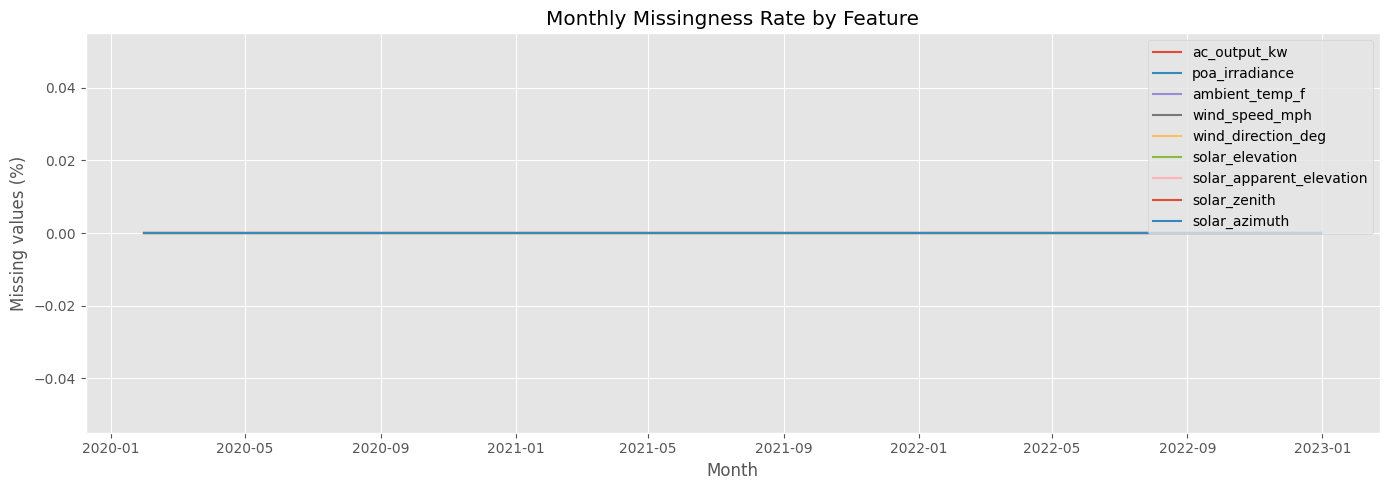

In [13]:
# Build a missingness-by-month view.
# This is more insightful than only reporting total missing rows... because it shows whether missing data clusters in particular periods.

monthly_missing = df_combined_full.isna().resample("M").mean() * 100

plt.figure(figsize=(14, 5))
for col in monthly_missing.columns:
    plt.plot(monthly_missing.index, monthly_missing[col], label=col)
plt.title("Monthly Missingness Rate by Feature")
plt.xlabel("Month")
plt.ylabel("Missing values (%)")
plt.legend()
plt.tight_layout()
plt.show()

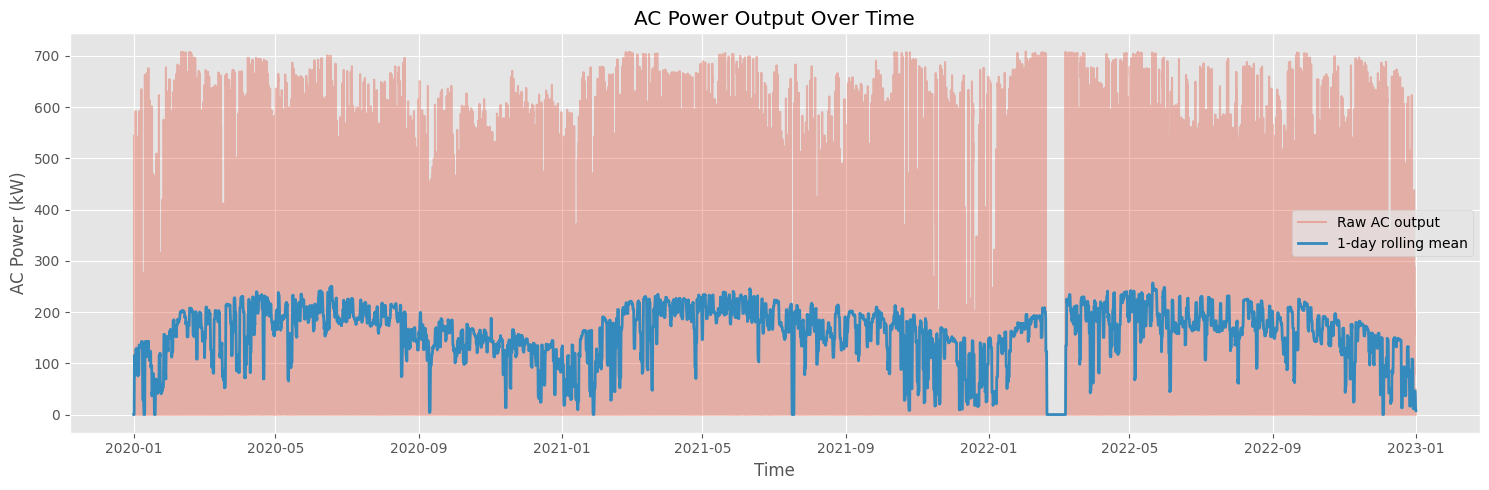

In [14]:
# Plot the full power series with a 1-day rolling average to make long-term changes and suspicious outages easier to see.

power_roll_day = df_combined_full["ac_output_kw"].rolling(96, min_periods=1).mean()

plt.figure(figsize=(15, 5))
plt.plot(df_combined_full.index, df_combined_full["ac_output_kw"], alpha=0.35, label="Raw AC output")
plt.plot(df_combined_full.index, power_roll_day, linewidth=2, label="1-day rolling mean")
plt.title("AC Power Output Over Time")
plt.xlabel("Time")
plt.ylabel("AC Power (kW)")
plt.legend()
plt.tight_layout()
plt.show()

This power plot is useful for checking whether the 2022 region contains abrupt low-output periods, data dropouts, or operational changes that a forecasting model should not simply treat as ordinary weather variation.

In [15]:
df_combined_full

# This cell simply displays the entire `df_combined_full` DataFrame, showing its current state after initial data ingestion, renaming, and sorting.

,ac_output_kw,poa_irradiance,ambient_temp_f,wind_speed_mph,wind_direction_deg,solar_elevation,solar_apparent_elevation,solar_zenith,solar_azimuth
measured_on,,,,,,,,,
2020-01-01 00:00:00-08:00,0.0,0.0,44.3,2.3,196.0,-73.841620,-73.841620,163.841620,350.218378
2020-01-01 00:15:00-08:00,0.0,0.0,44.3,2.3,196.0,-74.021761,-74.021761,164.021761,2.687778
2020-01-01 00:30:00-08:00,0.0,0.0,44.3,2.3,196.0,-73.572096,-73.572096,163.572096,14.967778
2020-01-01 00:45:00-08:00,0.0,0.0,44.3,2.3,196.0,-72.541693,-72.541693,162.541693,26.286888
2020-01-01 01:00:00-08:00,0.0,0.0,43.6,2.1,290.0,-71.025987,-71.025987,161.025987,36.219761
...,...,...,...,...,...,...,...,...,...
2022-12-31 22:45:00-08:00,0.0,0.0,48.8,4.5,260.0,-65.589560,-65.589560,155.589560,304.516142
2022-12-31 23:00:00-08:00,0.0,0.0,49.9,9.4,265.0,-67.893321,-67.893321,157.893321,311.030505
2022-12-31 23:15:00-08:00,0.0,0.0,49.9,9.4,265.0,-69.959350,-69.959350,159.959350,318.728950


In [16]:
# Create the target variable 'y'
y = df_combined_full['ac_output_kw']

# Create the features DataFrame 'X' by dropping the target variable
X = df_combined_full.drop('ac_output_kw', axis=1)

print("Target variable (y) head:")
display(y.head())

print("\nFeatures DataFrame (X) head:")
display(X.head())

# Separate the 'ac_output_kw' column into the target variable 'y' and the remaining columns into the features DataFrame 'X', preparing the data for machine learning modeling.

Target variable (y) head:


,ac_output_kw
measured_on,
2020-01-01 00:00:00-08:00,0.0
2020-01-01 00:15:00-08:00,0.0
2020-01-01 00:30:00-08:00,0.0
2020-01-01 00:45:00-08:00,0.0
2020-01-01 01:00:00-08:00,0.0



Features DataFrame (X) head:


,poa_irradiance,ambient_temp_f,wind_speed_mph,wind_direction_deg,solar_elevation,solar_apparent_elevation,solar_zenith,solar_azimuth
measured_on,,,,,,,,
2020-01-01 00:00:00-08:00,0.0,44.3,2.3,196.0,-73.841620,-73.841620,163.841620,350.218378
2020-01-01 00:15:00-08:00,0.0,44.3,2.3,196.0,-74.021761,-74.021761,164.021761,2.687778
2020-01-01 00:30:00-08:00,0.0,44.3,2.3,196.0,-73.572096,-73.572096,163.572096,14.967778
2020-01-01 00:45:00-08:00,0.0,44.3,2.3,196.0,-72.541693,-72.541693,162.541693,26.286888
2020-01-01 01:00:00-08:00,0.0,43.6,2.1,290.0,-71.025987,-71.025987,161.025987,36.219761


In [17]:
# We now keep the original current-time AC power as a separate series ('ac_output_current') and create the future target separately.
# This avoids leakage in terms of lag and rolling.

# Create a daytime-only view for solar analysis.
# This removes the regular nighttime zeros so daytime structure is easier to study.
# Filter out nighttime/zero irradiance rows where 'poa_irradiance' is 0
df_combined_full_daytime = df_combined_full[df_combined_full['poa_irradiance'].fillna(0) > 0].copy()

# --- NEW CHANGE: keep the ORIGINAL current-time power series for lag features ---
ac_output_current = df_combined_full_daytime['ac_output_kw'].copy()

# Create the features DataFrame 'X' from the daytime data
X = df_combined_full_daytime.drop('ac_output_kw', axis=1).copy()

# --- NEW CHANGE: define a separate forecasting target ---
# 1 hour ahead = 4 steps for 15-minute data
target_name = 'target_1h_ahead'
y = ac_output_current.shift(-4).rename(target_name)

print(f"Original DataFrame shape: {df_combined_full.shape}")
print(f"Daytime DataFrame shape: {df_combined_full_daytime.shape}")

print("\nCurrent-time power series head (used for lag/rolling features):")
display(ac_output_current.head())

print(f"\nFuture target head ({target_name}):")
display(y.head())

print("\nUpdated Features DataFrame (X) head after filtering:")
display(X.head())

# Yup.

Original DataFrame shape: (105192, 9)
Daytime DataFrame shape: (55805, 9)

Current-time power series head (used for lag/rolling features):


,ac_output_kw
measured_on,
2020-01-01 07:30:00-08:00,0.64
2020-01-01 07:45:00-08:00,4.48
2020-01-01 08:00:00-08:00,25.60
2020-01-01 08:15:00-08:00,75.52
2020-01-01 08:30:00-08:00,70.40



Future target head (target_1h_ahead):


,target_1h_ahead
measured_on,
2020-01-01 07:30:00-08:00,70.40
2020-01-01 07:45:00-08:00,41.60
2020-01-01 08:00:00-08:00,64.00
2020-01-01 08:15:00-08:00,104.32
2020-01-01 08:30:00-08:00,122.24



Updated Features DataFrame (X) head after filtering:


,poa_irradiance,ambient_temp_f,wind_speed_mph,wind_direction_deg,solar_elevation,solar_apparent_elevation,solar_zenith,solar_azimuth
measured_on,,,,,,,,
2020-01-01 07:30:00-08:00,1.2,42.5,2.3,241.0,-0.400702,0.089195,90.400702,119.821251
2020-01-01 07:45:00-08:00,6.0,42.5,2.3,241.0,2.096892,2.344862,87.903108,122.202422
2020-01-01 08:00:00-08:00,13.6,44.8,4.9,350.0,4.529018,4.683792,85.470982,124.654310
2020-01-01 08:15:00-08:00,137.8,44.8,4.9,350.0,6.889136,7.000633,83.110864,127.184194
2020-01-01 08:30:00-08:00,101.8,44.8,4.9,350.0,9.170212,9.257204,80.829788,129.799047


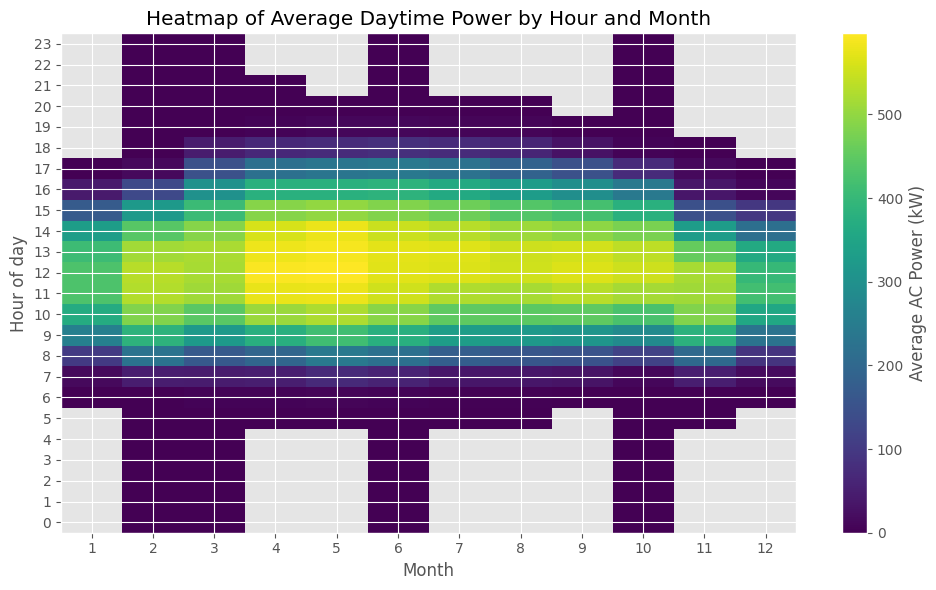

In [18]:
# More insightful graph:
# A month-by-hour heatmap of average power shows seasonality and diurnal shape together.

hour_month_power = (
    df_combined_full_daytime.assign(hour=df_combined_full_daytime.index.hour, month=df_combined_full_daytime.index.month)
    .groupby(["month", "hour"])["ac_output_kw"]
    .mean()
    .unstack(0)
)

plt.figure(figsize=(10, 6))
plt.imshow(hour_month_power, aspect="auto", origin="lower")
plt.colorbar(label="Average AC Power (kW)")
plt.xticks(range(hour_month_power.shape[1]), hour_month_power.columns)
plt.yticks(range(hour_month_power.shape[0]), hour_month_power.index)
plt.title("Heatmap of Average Daytime Power by Hour and Month")
plt.xlabel("Month")
plt.ylabel("Hour of day")
plt.tight_layout()
plt.show()

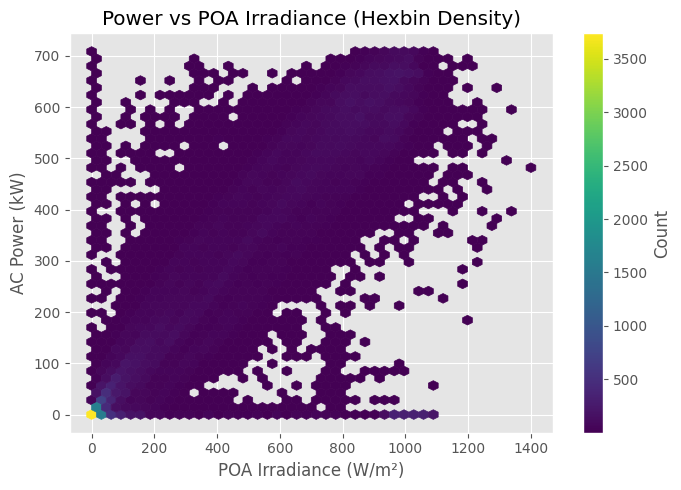

In [19]:
# Use a hexbin instead of a plain scatter plot.
# This gives a clearer picture of the density relationship between irradiance and power.

plt.figure(figsize=(7, 5))
plt.hexbin(
    df_combined_full_daytime["poa_irradiance"],
    df_combined_full_daytime["ac_output_kw"],
    gridsize=45,
    mincnt=1
)
plt.colorbar(label="Count")
plt.title("Power vs POA Irradiance (Hexbin Density)")
plt.xlabel("POA Irradiance (W/m²)")
plt.ylabel("AC Power (kW)")
plt.tight_layout()
plt.show()

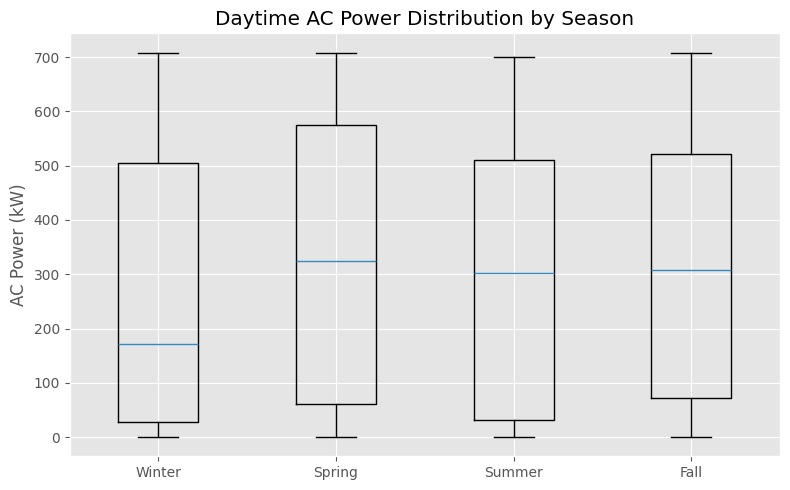

In [20]:
# Seasonal distribution plot to examine whether the system behaves differently across the year.

season_map = {
    12: "Winter", 1: "Winter", 2: "Winter",
    3: "Spring", 4: "Spring", 5: "Spring",
    6: "Summer", 7: "Summer", 8: "Summer",
    9: "Fall", 10: "Fall", 11: "Fall"
}

seasonal_df = df_combined_full_daytime.copy()
seasonal_df["season"] = seasonal_df.index.month.map(season_map)

season_order = ["Winter", "Spring", "Summer", "Fall"]
season_data = [seasonal_df.loc[seasonal_df["season"] == s, "ac_output_kw"].dropna() for s in season_order]

plt.figure(figsize=(8, 5))
plt.boxplot(season_data, tick_labels=season_order, showfliers=False)
plt.title("Daytime AC Power Distribution by Season")
plt.ylabel("AC Power (kW)")
plt.tight_layout()
plt.show()

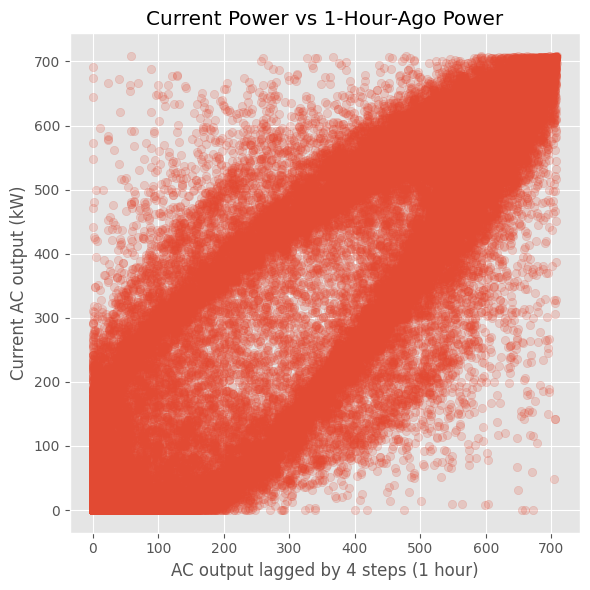

In [21]:
# Examine the autocorrelation idea visually with a lag plot.
# This helps justify persistence-style features and short-horizon forecasting.

lag_plot_df = df_combined_full_daytime[["ac_output_kw"]].copy()
lag_plot_df["ac_output_kw_lag4"] = lag_plot_df["ac_output_kw"].shift(4)
lag_plot_df = lag_plot_df.dropna()

plt.figure(figsize=(6, 6))
plt.scatter(
    lag_plot_df["ac_output_kw_lag4"],
    lag_plot_df["ac_output_kw"],
    alpha=0.2
)
plt.title("Current Power vs 1-Hour-Ago Power")
plt.xlabel("AC output lagged by 4 steps (1 hour)")
plt.ylabel("Current AC output (kW)")
plt.tight_layout()
plt.show()



---



## 2. Structured preprocessing and feature engineering

This is the main structural improvement. Instead of manually scaling arrays in separate places, the notebook now creates a more reusable preprocessing workflow.

In [22]:
forecast_steps = 4


In [23]:
X['hour'] = X.index.hour
X['day_of_week'] = X.index.dayofweek
X['day_of_year'] = X.index.dayofyear
X['month'] = X.index.month
X['week_of_year'] = X.index.isocalendar().week.astype(int)
X['year'] = X.index.year


# Hour of day
X["hour_sin"] = np.sin(2 * np.pi * X["hour"] / 24)
X["hour_cos"] = np.cos(2 * np.pi * X["hour"] / 24)

# Day of year
X["doy_sin"] = np.sin(2 * np.pi * X["day_of_year"] / 365.25)
X["doy_cos"] = np.cos(2 * np.pi * X["day_of_year"] / 365.25)

# Wind direction
X["wind_dir_sin"] = np.sin(2 * np.pi * X["wind_direction_deg"] / 360)
X["wind_dir_cos"] = np.cos(2 * np.pi * X["wind_direction_deg"] / 360)


print("Features DataFrame (X) head with new time features:")
display(X.head())

# Perform feature engineering by extracting various time-based features (hour, day of week, day of year, month, week of year, year) from the DataFrame's index and adding them as new columns to the features DataFrame 'X'.

Features DataFrame (X) head with new time features:


,poa_irradiance,ambient_temp_f,wind_speed_mph,wind_direction_deg,solar_elevation,solar_apparent_elevation,solar_zenith,solar_azimuth,hour,day_of_week,day_of_year,month,week_of_year,year,hour_sin,hour_cos,doy_sin,doy_cos,wind_dir_sin,wind_dir_cos
measured_on,,,,,,,,,,,,,,,,,,,,
2020-01-01 07:30:00-08:00,1.2,42.5,2.3,241.0,-0.400702,0.089195,90.400702,119.821251,7,2,1,1,1,2020,0.965926,-0.258819,0.017202,0.999852,-0.874620,-0.484810
2020-01-01 07:45:00-08:00,6.0,42.5,2.3,241.0,2.096892,2.344862,87.903108,122.202422,7,2,1,1,1,2020,0.965926,-0.258819,0.017202,0.999852,-0.874620,-0.484810
2020-01-01 08:00:00-08:00,13.6,44.8,4.9,350.0,4.529018,4.683792,85.470982,124.654310,8,2,1,1,1,2020,0.866025,-0.500000,0.017202,0.999852,-0.173648,0.984808
2020-01-01 08:15:00-08:00,137.8,44.8,4.9,350.0,6.889136,7.000633,83.110864,127.184194,8,2,1,1,1,2020,0.866025,-0.500000,0.017202,0.999852,-0.173648,0.984808
2020-01-01 08:30:00-08:00,101.8,44.8,4.9,350.0,9.170212,9.257204,80.829788,129.799047,8,2,1,1,1,2020,0.866025,-0.500000,0.017202,0.999852,-0.173648,0.984808


In [24]:
# Lag features must come from the ORIGINAL observed power series (ac_output_current), not from the already shifted future target y.

# Lag features for current observed AC power...1, 4 and 8
X['ac_output_kw_lag1'] = ac_output_current.shift(1)
#---X['ac_output_kw_lag2'] = ac_output_current.shift(2)
X['ac_output_kw_lag4'] = ac_output_current.shift(4)
X['ac_output_kw_lag8'] = ac_output_current.shift(8)

# Lag feature for POA irradiance...1 and 4
X['poa_irradiance_lag1'] = X['poa_irradiance'].shift(1)
X['poa_irradiance_lag4'] = X['poa_irradiance'].shift(4)

print("Features DataFrame (X) head with corrected lag features:")
display(X.head())

# Create lag features from past observed values so the model only uses information that would have been available at prediction time.

Features DataFrame (X) head with corrected lag features:


,poa_irradiance,ambient_temp_f,wind_speed_mph,wind_direction_deg,solar_elevation,solar_apparent_elevation,solar_zenith,solar_azimuth,hour,day_of_week,day_of_year,month,week_of_year,year,hour_sin,hour_cos,doy_sin,doy_cos,wind_dir_sin,wind_dir_cos,ac_output_kw_lag1,ac_output_kw_lag4,ac_output_kw_lag8,poa_irradiance_lag1,poa_irradiance_lag4
measured_on,,,,,,,,,,,,,,,,,,,,,,,,,
2020-01-01 07:30:00-08:00,1.2,42.5,2.3,241.0,-0.400702,0.089195,90.400702,119.821251,7,2,1,1,1,2020,0.965926,-0.258819,0.017202,0.999852,-0.874620,-0.484810,NaN,NaN,NaN,NaN,NaN
2020-01-01 07:45:00-08:00,6.0,42.5,2.3,241.0,2.096892,2.344862,87.903108,122.202422,7,2,1,1,1,2020,0.965926,-0.258819,0.017202,0.999852,-0.874620,-0.484810,0.64,NaN,NaN,1.2,NaN
2020-01-01 08:00:00-08:00,13.6,44.8,4.9,350.0,4.529018,4.683792,85.470982,124.654310,8,2,1,1,1,2020,0.866025,-0.500000,0.017202,0.999852,-0.173648,0.984808,4.48,NaN,NaN,6.0,NaN
2020-01-01 08:15:00-08:00,137.8,44.8,4.9,350.0,6.889136,7.000633,83.110864,127.184194,8,2,1,1,1,2020,0.866025,-0.500000,0.017202,0.999852,-0.173648,0.984808,25.60,NaN,NaN,13.6,NaN
2020-01-01 08:30:00-08:00,101.8,44.8,4.9,350.0,9.170212,9.257204,80.829788,129.799047,8,2,1,1,1,2020,0.866025,-0.500000,0.017202,0.999852,-0.173648,0.984808,75.52,0.64,NaN,137.8,1.2


In [25]:
# Rolling statistics for AC power must also come from the ORIGINAL observed power series, not from the shifted future target.

# Rolling features for current observed AC power...4, 8 and 8
#---X['ac_output_kw_roll3'] = ac_output_current.shift(1).rolling(window=3).mean()
X['ac_output_kw_roll4'] = ac_output_current.shift(1).rolling(window=4).mean()
#---X['ac_output_kw_roll6'] = ac_output_current.shift(1).rolling(window=6).mean()
X['ac_output_kw_roll8'] = ac_output_current.shift(1).rolling(window=8).mean()
#---X['ac_output_kw_std3']  = ac_output_current.shift(1).rolling(window=3).std()
X['ac_output_kw_std8']  = ac_output_current.shift(1).rolling(window=8).std()

# Rolling features for POA irradiance...4 and 8
#---X['poa_irradiance_roll3'] = X['poa_irradiance'].shift(1).rolling(window=3).mean()
X['poa_irradiance_roll4'] = X['poa_irradiance'].shift(1).rolling(window=4).mean()
#---X['poa_irradiance_roll6'] = X['poa_irradiance'].shift(1).rolling(window=6).mean()
X['poa_irradiance_roll8'] = X['poa_irradiance'].shift(1).rolling(window=8).mean()

print("Features DataFrame (X) head with corrected rolling features:")
display(X.head())

# Rolling features summarize recent history and add short-term temporal context without leaking future information.

Features DataFrame (X) head with corrected rolling features:


,poa_irradiance,ambient_temp_f,wind_speed_mph,wind_direction_deg,solar_elevation,solar_apparent_elevation,solar_zenith,solar_azimuth,hour,day_of_week,day_of_year,month,week_of_year,year,hour_sin,hour_cos,doy_sin,doy_cos,wind_dir_sin,wind_dir_cos,ac_output_kw_lag1,ac_output_kw_lag4,ac_output_kw_lag8,poa_irradiance_lag1,poa_irradiance_lag4,ac_output_kw_roll4,ac_output_kw_roll8,ac_output_kw_std8,poa_irradiance_roll4,poa_irradiance_roll8
measured_on,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2020-01-01 07:30:00-08:00,1.2,42.5,2.3,241.0,-0.400702,0.089195,90.400702,119.821251,7,2,1,1,1,2020,0.965926,-0.258819,0.017202,0.999852,-0.874620,-0.484810,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-01 07:45:00-08:00,6.0,42.5,2.3,241.0,2.096892,2.344862,87.903108,122.202422,7,2,1,1,1,2020,0.965926,-0.258819,0.017202,0.999852,-0.874620,-0.484810,0.64,NaN,NaN,1.2,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-01 08:00:00-08:00,13.6,44.8,4.9,350.0,4.529018,4.683792,85.470982,124.654310,8,2,1,1,1,2020,0.866025,-0.500000,0.017202,0.999852,-0.173648,0.984808,4.48,NaN,NaN,6.0,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-01 08:15:00-08:00,137.8,44.8,4.9,350.0,6.889136,7.000633,83.110864,127.184194,8,2,1,1,1,2020,0.866025,-0.500000,0.017202,0.999852,-0.173648,0.984808,25.60,NaN,NaN,13.6,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-01 08:30:00-08:00,101.8,44.8,4.9,350.0,9.170212,9.257204,80.829788,129.799047,8,2,1,1,1,2020,0.866025,-0.500000,0.017202,0.999852,-0.173648,0.984808,75.52,0.64,NaN,137.8,1.2,26.56,NaN,NaN,39.65,NaN


In [26]:
# Daytime flag
X["is_daytime"] = (X["poa_irradiance"].fillna(0) > 0).astype(int)

# Future target
#---X["target_1h_ahead"] = X["ac_output_kw"].shift(-forecast_steps)
X["target_1h_ahead"] = ac_output_current.shift(-forecast_steps)

In [27]:
# Restrict training and testing to the requested periods.
# We also keep only daytime rows for the forecasting setup because the project is primarily about solar production behavior.

df_supervised = X.loc["2020-01-01":"2022-12-31"].copy()
df_supervised = df_supervised[df_supervised["is_daytime"] == 1].copy()

#---feature_cols = ["poa_irradiance", "ambient_temp_f", "wind_speed_mph", "wind_direction_deg", "solar_elevation", "solar_apparent_elevation", "solar_zenith", "solar_azimuth", "hour", "day_of_week", "day_of_year", "month", "hour_sin", "hour_cos", "doy_sin", "doy_cos", "wind_dir_sin", "wind_dir_cos", "ac_output_kw_lag1", "ac_output_kw_lag4", "ac_output_kw_lag8", "poa_irradiance_lag1", "poa_irradiance_lag4", "ac_output_kw_roll4", "ac_output_kw_roll8", "ac_output_kw_std8", "poa_irradiance_roll4", "poa_irradiance_roll8"]
#---feature_cols = ["poa_irradiance", "ambient_temp_f", "wind_speed_mph", "wind_direction_deg", "solar_elevation", "solar_apparent_elevation", "solar_zenith", "solar_azimuth", "hour", "day_of_week", "day_of_year", "month", "week_of_year", "year", "hour_sin", "hour_cos", "doy_sin", "doy_cos", "wind_dir_sin", "wind_dir_cos", "ac_output_kw_lag1", "ac_output_kw_lag2", "ac_output_kw_lag4", "ac_output_kw_lag8", "poa_irradiance_lag1", "poa_irradiance_lag4", "ac_output_kw_roll3", "ac_output_kw_roll4", "ac_output_kw_roll6", "ac_output_kw_roll8", "ac_output_kw_std3", "ac_output_kw_std8", "poa_irradiance_roll3", "poa_irradiance_roll4", "poa_irradiance_roll6", "poa_irradiance_roll8"]

#---feature_cols = ["poa_irradiance", "ambient_temp_f", "wind_speed_mph", "wind_direction_deg", "solar_elevation", "solar_apparent_elevation", "solar_zenith", "solar_azimuth", "hour", "day_of_week", "day_of_year", "month", "week_of_year", "year", "hour_sin", "hour_cos", "doy_sin", "doy_cos", "wind_dir_sin", "wind_dir_cos", "ac_output_kw_lag1", "ac_output_kw_lag2", "ac_output_kw_lag4", "poa_irradiance_lag1", "ac_output_kw_roll3", "ac_output_kw_roll6", "ac_output_kw_std3", "poa_irradiance_roll3", "poa_irradiance_roll6"]

feature_cols = [
    "ambient_temp_f", "wind_speed_mph", "wind_direction_deg", "poa_irradiance",
    "hour", "day_of_week", "day_of_year", "month",
    "hour_sin", "hour_cos", "doy_sin", "doy_cos", "wind_dir_sin", "wind_dir_cos",
    "ac_output_kw_lag1", "ac_output_kw_lag4", "ac_output_kw_lag8",
    "poa_irradiance_lag1", "poa_irradiance_lag4",
    "ac_output_kw_roll4", "ac_output_kw_roll8", "ac_output_kw_std8",
    "poa_irradiance_roll4", "poa_irradiance_roll8",

    "solar_elevation", "solar_apparent_elevation", "solar_zenith", "solar_azimuth",
    "week_of_year", "year"
]


df_supervised = df_supervised[feature_cols + ["target_1h_ahead"]].dropna()
#---df_supervised = df_supervised[feature_cols + ["target_1h_ahead"]]

X = df_supervised[feature_cols].copy()
y = df_supervised["target_1h_ahead"].copy()

X_train = X.loc["2020-01-01":"2021-12-31"].copy()
y_train = y.loc["2020-01-01":"2021-12-31"].copy()

X_test = X.loc["2022-01-01":"2022-12-31"].copy()
y_test = y.loc["2022-01-01":"2022-12-31"].copy()

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)
display(X_train.head())

X_train: (36219, 30)
X_test : (19574, 30)
y_train: (36219,)
y_test : (19574,)


,ambient_temp_f,wind_speed_mph,wind_direction_deg,poa_irradiance,hour,day_of_week,day_of_year,month,hour_sin,hour_cos,doy_sin,doy_cos,wind_dir_sin,wind_dir_cos,ac_output_kw_lag1,ac_output_kw_lag4,ac_output_kw_lag8,poa_irradiance_lag1,poa_irradiance_lag4,ac_output_kw_roll4,ac_output_kw_roll8,ac_output_kw_std8,poa_irradiance_roll4,poa_irradiance_roll8,solar_elevation,solar_apparent_elevation,solar_zenith,solar_azimuth,week_of_year,year
measured_on,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2020-01-01 09:30:00-08:00,49.5,1.9,3.0,125.3,9,2,1,1,0.707107,-0.707107,0.017202,0.999852,0.052336,0.998630,104.32,70.40,0.64,140.4,101.8,70.08,48.32,36.578514,90.125,64.8875,17.345589,17.392135,72.654411,141.229494,1,2020
2020-01-01 09:45:00-08:00,49.5,1.9,3.0,215.0,9,2,1,1,0.707107,-0.707107,0.017202,0.999852,0.052336,0.998630,122.24,41.60,4.48,125.3,88.1,83.04,63.52,39.112252,96.000,80.4000,19.108357,19.150491,70.891643,144.352877,1,2020
2020-01-01 10:00:00-08:00,49.7,2.6,72.0,271.8,10,2,1,1,0.500000,-0.866025,0.017202,0.999852,0.951057,0.309017,142.72,64.00,25.60,215.0,30.2,108.32,80.80,39.832702,127.725,106.5250,20.739774,20.778412,69.260226,147.587391,1,2020
2020-01-01 10:15:00-08:00,49.7,2.6,72.0,482.9,10,2,1,1,0.500000,-0.866025,0.017202,0.999852,0.951057,0.309017,227.84,104.32,75.52,271.8,140.4,149.28,106.08,59.242363,188.125,138.8000,22.229975,22.265851,67.770025,150.932402,1,2020
2020-01-01 10:30:00-08:00,49.7,2.6,72.0,669.2,10,2,1,1,0.500000,-0.866025,0.017202,0.999852,0.951057,0.309017,349.44,122.24,70.40,482.9,125.3,210.56,140.32,102.454700,273.750,181.9375,23.569120,23.602787,66.430880,154.385031,1,2020


In [28]:
"""


# Combine X and y to drop NaNs consistently across both...  NOTE: y is now the separate 1-hour-ahead target column.
df_supervised = pd.concat([X, y], axis=1)
df_supervised.dropna(inplace=True)

# Separate X and y again after dropping NaNs
X = df_supervised.drop(columns=[target_name])
y = df_supervised[target_name]

print(f"Shape of X after dropping NaNs: {X.shape}")
print(f"Shape of y after dropping NaNs: {y.shape}")

print("\nFeatures DataFrame (X) head after dropping NaNs:")
display(X.head())

print("\nTarget variable (y) head after dropping NaNs:")
display(y.head())

# Final supervised learning table with aligned predictors and the future target.


"""

'\n\n\n# Combine X and y to drop NaNs consistently across both...  NOTE: y is now the separate 1-hour-ahead target column.\ndf_supervised = pd.concat([X, y], axis=1)\ndf_supervised.dropna(inplace=True)\n\n# Separate X and y again after dropping NaNs\nX = df_supervised.drop(columns=[target_name])\ny = df_supervised[target_name]\n\nprint(f"Shape of X after dropping NaNs: {X.shape}")\nprint(f"Shape of y after dropping NaNs: {y.shape}")\n\nprint("\nFeatures DataFrame (X) head after dropping NaNs:")\ndisplay(X.head())\n\nprint("\nTarget variable (y) head after dropping NaNs:")\ndisplay(y.head())\n\n# Final supervised learning table with aligned predictors and the future target.\n\n\n'

In [29]:
"""


# Split X and y into training and testing sets based on the defined periods
X_train = X.loc['2020-01-01':'2021-12-31']
y_train = y.loc['2020-01-01':'2021-12-31']

X_test = X.loc['2022-01-01':'2022-12-31']
y_test = y.loc['2022-01-01':'2022-12-31']

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_test: {y_test.shape}")

print("\nHead of X_train:")
display(X_train.head())

print("\nHead of y_train:")
display(y_train.head())

print("\nHead of X_test:")
display(X_test.head())

print("\nHead of y_test:")
display(y_test.head())

# Create the final training and testing datasets ('X_train', 'y_train', 'X_test', 'y_test') by splitting the processed feature table and the 1-hour-ahead target based on the predefined date ranges (2020-2021 for training, 2022 for testing).


"""

'\n\n\n# Split X and y into training and testing sets based on the defined periods\nX_train = X.loc[\'2020-01-01\':\'2021-12-31\']\ny_train = y.loc[\'2020-01-01\':\'2021-12-31\']\n\nX_test = X.loc[\'2022-01-01\':\'2022-12-31\']\ny_test = y.loc[\'2022-01-01\':\'2022-12-31\']\n\nprint(f"Shape of X_train: {X_train.shape}")\nprint(f"Shape of y_train: {y_train.shape}")\nprint(f"Shape of X_test: {X_test.shape}")\nprint(f"Shape of y_test: {y_test.shape}")\n\nprint("\nHead of X_train:")\ndisplay(X_train.head())\n\nprint("\nHead of y_train:")\ndisplay(y_train.head())\n\nprint("\nHead of X_test:")\ndisplay(X_test.head())\n\nprint("\nHead of y_test:")\ndisplay(y_test.head())\n\n# Create the final training and testing datasets (\'X_train\', \'y_train\', \'X_test\', \'y_test\') by splitting the processed feature table and the 1-hour-ahead target based on the predefined date ranges (2020-2021 for training, 2022 for testing).\n\n\n'

In [30]:
#---feature_cols = ["poa_irradiance", "ambient_temp_f", "wind_speed_mph", "wind_direction_deg", "solar_elevation", "solar_apparent_elevation", "solar_zenith", "solar_azimuth", "hour", "day_of_week", "day_of_year", "month", "week_of_year", "year", "hour_sin", "hour_cos", "doy_sin", "doy_cos", "wind_dir_sin", "wind_dir_cos", "ac_output_kw_lag1", "ac_output_kw_lag2", "ac_output_kw_lag4", "ac_output_kw_lag8", "poa_irradiance_lag1", "poa_irradiance_lag4", "ac_output_kw_roll3", "ac_output_kw_roll4", "ac_output_kw_roll6", "ac_output_kw_roll8", "ac_output_kw_std3", "ac_output_kw_std8", "poa_irradiance_roll3", "poa_irradiance_roll4", "poa_irradiance_roll6", "poa_irradiance_roll8"]

In [31]:
feature_colsg = {
    "weather": [
        "poa_irradiance",
        "ambient_temp_f",
        "wind_speed_mph",
        "wind_direction_deg",
    ],

    "solar_geometry": [
        "solar_elevation",
        "solar_apparent_elevation",
        "solar_zenith",
        "solar_azimuth",
    ],

    "time_raw": [
        "hour",
        "day_of_week",
        "day_of_year",
        "month",
        "week_of_year",
        "year",
    ],

    "time_cyclical": [
        "hour_sin",
        "hour_cos",
        "doy_sin",
        "doy_cos",
    ],

    "wind_cyclical": [
        "wind_dir_sin",
        "wind_dir_cos",
    ],

    "lags": [
        "ac_output_kw_lag1",
        "ac_output_kw_lag2",
        "ac_output_kw_lag4",
        "ac_output_kw_lag8",
        "poa_irradiance_lag1",
        "poa_irradiance_lag4",
    ],

    "rolling_means": [
        "ac_output_kw_roll3",
        "ac_output_kw_roll4",
        "ac_output_kw_roll6",
        "ac_output_kw_roll8",
        "poa_irradiance_roll3",
        "poa_irradiance_roll4",
        "poa_irradiance_roll6",
        "poa_irradiance_roll8",
    ],

    "rolling_std": [
        "ac_output_kw_std3",
        "ac_output_kw_std8",
    ],
}

In [32]:
#--- flat_feature_cols = [col for group in feature_cols.values() for col in group]

In [33]:
# Build a reusable preprocessing pipeline.
# For XGBoost, scaling is not strictly required, but creating a pipeline here gives the notebook better structure and makes it easy to compare future models.

numeric_features = feature_cols

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", RobustScaler())
            ]),
            numeric_features
        )
    ],
    remainder="drop"
)

X_train_prepared = preprocessor.fit_transform(X_train)
X_test_prepared = preprocessor.transform(X_test)

print("Prepared train shape:", X_train_prepared.shape)
print("Prepared test shape :", X_test_prepared.shape)

Prepared train shape: (36219, 30)
Prepared test shape : (19574, 30)


In [34]:
print("--- Final Data Structures ---")

print(f"\nShape of X_train_prepared: {X_train_prepared.shape}")
print("First 5 rows of X_train_prepared:\n", X_train_prepared[:5])

print(f"\nShape of y_train: {y_train.shape}")
print("Head of y_train:")
display(y_train.head())

print(f"\nShape of X_test_prepared: {X_test_prepared.shape}")
print("First 5 rows of X_test_prepared:\n", X_test_prepared[:5])

print(f"\nShape of y_test: {y_test.shape}")
print("Head of y_test:")
display(y_test.head())

# Display the shapes and the first five rows of the final processed and scaled or prepared training and testing features ('X_train_prepared', 'X_test_prepared') and their corresponding target variables ('y_train', 'y_test'), confirming the data's readiness for model building.

--- Final Data Structures ---

Shape of X_train_prepared: (36219, 30)
First 5 rows of X_train_prepared:
 [[-0.9017094  -0.68       -1.01538462 -0.46545236 -0.5        -0.25
  -1.12578616 -1.          0.5         0.         -0.01215632  0.88157825
  -0.45969242  0.82455036 -0.42265193 -0.49585635 -0.64640884 -0.44272166
  -0.50082794 -0.51287478 -0.58234641 -0.34305889 -0.54844032 -0.60939211
  -0.36017294 -0.35997242  0.36017294 -0.32053531 -1.08695652  0.        ]
 [-0.9017094  -0.68       -1.01538462 -0.330423   -0.5        -0.25
  -1.12578616 -1.          0.5         0.         -0.01215632  0.88157825
  -0.45969242  0.82455036 -0.3839779  -0.55801105 -0.63812155 -0.46545236
  -0.52145115 -0.48430335 -0.54718727 -0.30531974 -0.53931712 -0.58433975
  -0.30194548 -0.30181509  0.30194548 -0.29434038 -1.08695652  0.        ]
 [-0.89316239 -0.54       -0.48461538 -0.24491946 -0.33333333 -0.25
  -1.12578616 -1.          0.35355339 -0.26172095 -0.01215632  0.88157825
   0.43318231  0.389707

,target_1h_ahead
measured_on,
2020-01-01 09:30:00-08:00,472.960000
2020-01-01 09:45:00-08:00,517.760000
2020-01-01 10:00:00-08:00,535.039996
2020-01-01 10:15:00-08:00,545.280000
2020-01-01 10:30:00-08:00,384.640000



Shape of X_test_prepared: (19574, 30)
First 5 rows of X_test_prepared:
 [[-1.54273504 -0.48        1.32307692 -0.65321893 -0.83333333  0.5
  -1.12578616 -1.          0.6830127   0.73827905 -0.01215632  0.88157825
  -1.30512865  0.57433477 -0.64779006 -0.60220994 -0.22928177 -0.64955592
  -0.32108987 -0.64867725 -0.52239082  0.26620566 -0.54176291 -0.31611194
  -1.03115087 -1.0333634   1.03115087 -0.52005434  1.13043478  2.        ]
 [-1.54273504 -0.48        1.32307692 -0.64403633 -0.83333333  0.5
  -1.12578616 -1.          0.6830127   0.73827905 -0.01215632  0.88157825
  -1.30512865  0.57433477 -0.64779006 -0.62569061 -0.30248619 -0.65321893
  -0.43820563 -0.66031746 -0.5784604   0.06273501 -0.62741749 -0.41592437
  -0.94663642 -0.93207318  0.94663642 -0.50061567  1.13043478  2.        ]
 [-1.54273504 -0.48        1.32307692 -0.6216067  -0.83333333  0.5
  -1.12578616 -1.          0.6830127   0.73827905 -0.01215632  0.88157825
  -1.30512865  0.57433477 -0.63674033 -0.64226519 -0.37430

,target_1h_ahead
measured_on,
2022-01-01 07:15:00-08:00,151.04
2022-01-01 07:30:00-08:00,155.52
2022-01-01 07:45:00-08:00,158.08
2022-01-01 08:00:00-08:00,228.48
2022-01-01 08:15:00-08:00,294.40


In [35]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Normalize the numerical features in 'X_train' and 'X_test' using 'StandardScaler' to ensure all features contribute equally to model training, creating 'X_train_scaled' and 'X_test_scaled'.

In [36]:
print("--- Final Data Structures ---")

print(f"\nShape of X_train_scaled: {X_train_scaled.shape}")
print("First 5 rows of X_train_scaled:\n", X_train_scaled[:5])

print(f"\nShape of y_train: {y_train.shape}")
print("Head of y_train:")
display(y_train.head())

print(f"\nShape of X_test_scaled: {X_test_scaled.shape}")
print("First 5 rows of X_test_scaled:\n", X_test_scaled[:5])

print(f"\nShape of y_test: {y_test.shape}")
print("Head of y_test:")
display(y_test.head())

# Display the shapes and the first five rows of the final processed and scaled training and testing features ('X_train_scaled', 'X_test_scaled') and their corresponding target variables ('y_train', 'y_test'), confirming the data's readiness for model building.

--- Final Data Structures ---

Shape of X_train_scaled: (36219, 30)
First 5 rows of X_train_scaled:
 [[-1.39120162e+00 -1.09124793e+00 -1.51065422e+00 -9.71541982e-01
  -9.14798150e-01 -5.01643100e-01 -1.83271430e+00 -1.69591601e+00
   1.07654100e+00 -3.19726674e-01  5.15197366e-04  1.58356033e+00
  -4.11802524e-01  1.34517621e+00 -8.61140490e-01 -1.00635439e+00
  -1.30481403e+00 -9.27402422e-01 -1.04027180e+00 -1.02545991e+00
  -1.15868422e+00 -6.25648814e-01 -1.10200750e+00 -1.21768323e+00
  -6.46578243e-01 -6.48283914e-01  6.46578243e-01 -5.72665893e-01
  -1.80758262e+00 -9.98592889e-01]
 [-1.39120162e+00 -1.09124793e+00 -1.51065422e+00 -7.09200582e-01
  -9.14798150e-01 -5.01643100e-01 -1.83271430e+00 -1.69591601e+00
   1.07654100e+00 -3.19726674e-01  5.15197366e-04  1.58356033e+00
  -4.11802524e-01  1.34517621e+00 -7.84442880e-01 -1.12962079e+00
  -1.28837933e+00 -9.71565240e-01 -1.08033962e+00 -9.69013308e-01
  -1.09020863e+00 -5.68291987e-01 -1.08438405e+00 -1.16956906e+00
  -5.5

,target_1h_ahead
measured_on,
2020-01-01 09:30:00-08:00,472.960000
2020-01-01 09:45:00-08:00,517.760000
2020-01-01 10:00:00-08:00,535.039996
2020-01-01 10:15:00-08:00,545.280000
2020-01-01 10:30:00-08:00,384.640000



Shape of X_test_scaled: (19574, 30)
First 5 rows of X_test_scaled:
 [[-2.39933533e+00 -8.60136035e-01  1.37375393e+00 -1.33634374e+00
  -1.44601527e+00  1.00199923e+00 -1.83271430e+00 -1.69591601e+00
   1.43986194e+00  8.47271209e-01  5.15197366e-04  1.58356033e+00
  -1.85572722e+00  8.17477631e-01 -1.30763015e+00 -1.21727690e+00
  -4.77600935e-01 -1.32925482e+00 -6.91067576e-01 -1.29375547e+00
  -1.04191533e+00  3.00325561e-01 -1.08910863e+00 -6.54425662e-01
  -1.65893662e+00 -1.66528783e+00  1.65893662e+00 -9.28232464e-01
   1.81933811e+00  3.00141108e+00]
 [-2.39933533e+00 -8.60136035e-01  1.37375393e+00 -1.31850335e+00
  -1.44601527e+00  1.00199923e+00 -1.83271430e+00 -1.69591601e+00
   1.43986194e+00  8.47271209e-01  5.15197366e-04  1.58356033e+00
  -1.85572722e+00  8.17477631e-01 -1.30763015e+00 -1.26384421e+00
  -6.22774094e-01 -1.33637156e+00 -9.18606008e-01 -1.31675223e+00
  -1.15111586e+00 -8.91384673e-03 -1.25456909e+00 -8.46119851e-01
  -1.53142287e+00 -1.51231199e+00  1.5

,target_1h_ahead
measured_on,
2022-01-01 07:15:00-08:00,151.04
2022-01-01 07:30:00-08:00,155.52
2022-01-01 07:45:00-08:00,158.08
2022-01-01 08:00:00-08:00,228.48
2022-01-01 08:15:00-08:00,294.40




---



## 3. Exploratory Data Analysis

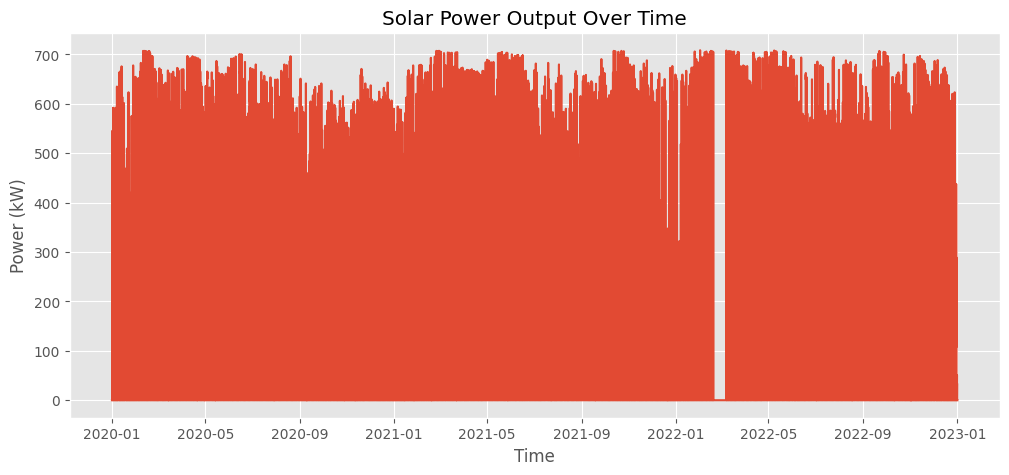

In [37]:
plt.figure(figsize=(12,5))
plt.plot(df_combined_full.index, df_combined_full["ac_output_kw"])
plt.title("Solar Power Output Over Time")
plt.xlabel("Time")
plt.ylabel("Power (kW)")
plt.show()

The Solar Power Output Over Time plot shows how the system’s power generation varies between 2020 and 2022, with output typically ranging between about 550 kW and 720 kW during active production periods. The fluctuations reflect normal changes in solar conditions such as cloud cover, seasonal variation, and daily irradiance patterns. A noticeable drop to near zero around early 2022 likely indicates missing data, maintenance downtime, or a temporary system outage.

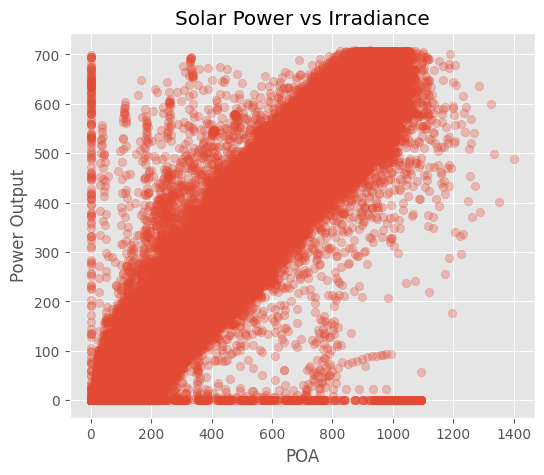

In [38]:
plt.figure(figsize=(6,5))
plt.scatter(df_combined_full["poa_irradiance"],
            df_combined_full["ac_output_kw"],
            alpha=0.3)

plt.xlabel("POA")
plt.ylabel("Power Output")
plt.title("Solar Power vs Irradiance")
plt.show()

The Solar Power vs Irradiance scatter plot shows a strong positive relationship between plane-of-array (POA) irradiance and power output, indicating that higher sunlight levels generally produce higher power generation. As irradiance increases, the power output rises and eventually begins to level off near the system’s maximum capacity (around 700 kW). The points near zero power across different irradiance levels likely represent nighttime values, sensor noise, or system downtime.

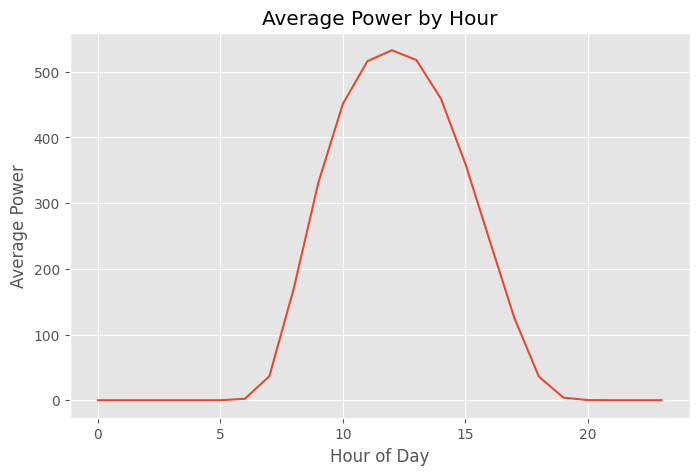

In [39]:
df_combined_full['hour'] = df_combined_full.index.hour

hourly_power = df_combined_full.groupby('hour')['ac_output_kw'].mean()

hourly_power.plot(kind='line', figsize=(8,5))
plt.title('Average Power by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Average Power')
plt.show()

The Average Power by Hour plot shows the typical daily solar generation pattern of the system. Power output begins increasing in the morning around 7–8 AM, peaks around noon to early afternoon, and then gradually declines toward the evening as sunlight decreases. This bell-shaped curve reflects the natural daily cycle of solar irradiance and confirms that the system produces the most energy during midday hours.

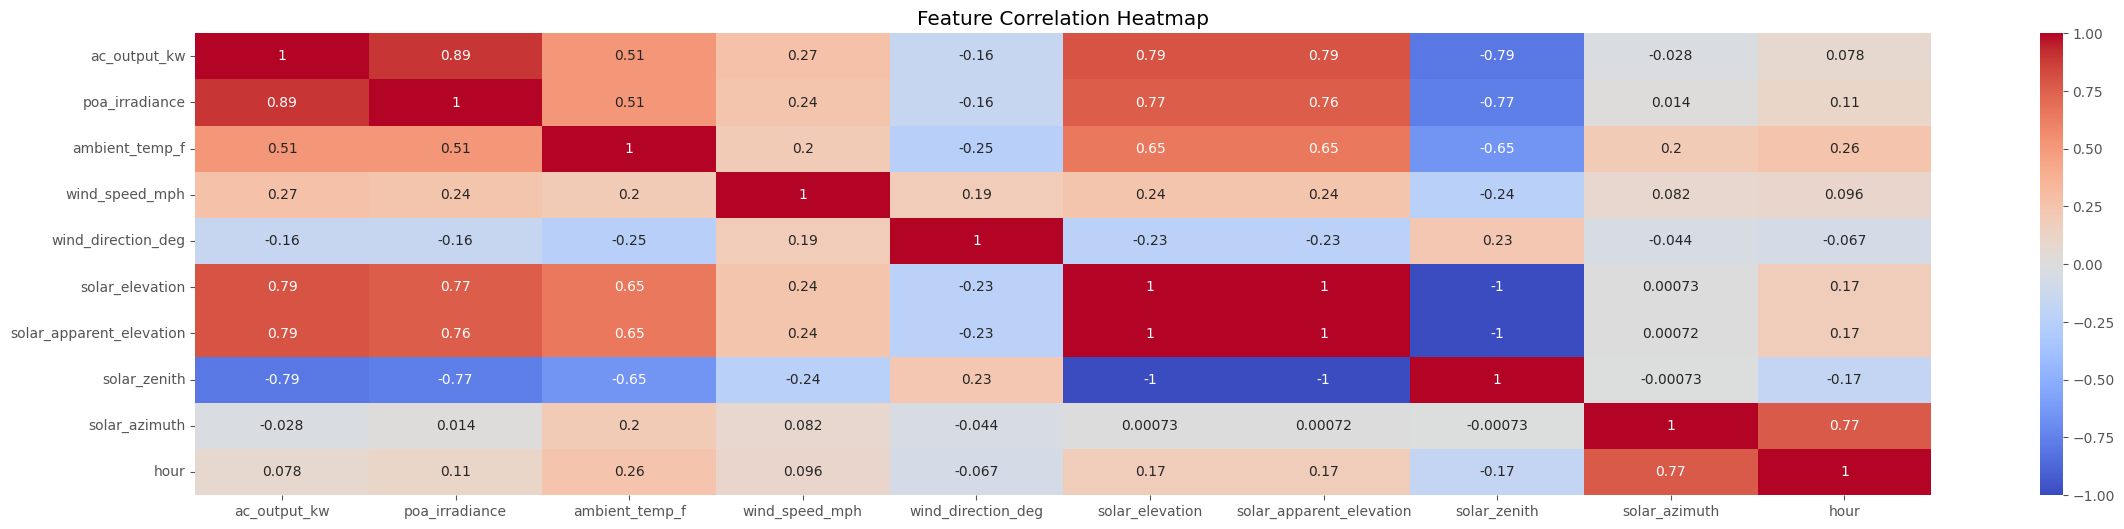


--- Correlation Matrix ---


,ac_output_kw,poa_irradiance,ambient_temp_f,wind_speed_mph,wind_direction_deg,solar_elevation,solar_apparent_elevation,solar_zenith,solar_azimuth,hour
ac_output_kw,1.000000,0.892785,0.514801,0.269701,-0.161746,0.792569,0.792242,-0.792569,-0.028358,0.077505
poa_irradiance,0.892785,1.000000,0.509519,0.244211,-0.161215,0.765199,0.764887,-0.765199,0.013920,0.107026
ambient_temp_f,0.514801,0.509519,1.000000,0.200232,-0.252982,0.652899,0.652757,-0.652899,0.197592,0.256699
wind_speed_mph,0.269701,0.244211,0.200232,1.000000,0.189198,0.242476,0.242406,-0.242476,0.082072,0.095719
wind_direction_deg,-0.161746,-0.161215,-0.252982,0.189198,1.000000,-0.231546,-0.231504,0.231546,-0.044472,-0.067201
solar_elevation,0.792569,0.765199,0.652899,0.242476,-0.231546,1.000000,0.999999,-1.000000,0.000733,0.174645
solar_apparent_elevation,0.792242,0.764887,0.652757,0.242406,-0.231504,0.999999,1.000000,-0.999999,0.000723,0.174688
solar_zenith,-0.792569,-0.765199,-0.652899,-0.242476,0.231546,-1.000000,-0.999999,1.000000,-0.000733,-0.174645
solar_azimuth,-0.028358,0.013920,0.197592,0.082072,-0.044472,0.000733,0.000723,-0.000733,1.000000,0.768800
hour,0.077505,0.107026,0.256699,0.095719,-0.067201,0.174645,0.174688,-0.174645,0.768800,1.000000


In [40]:
corr = df_combined_full.corr()

plt.figure(figsize=(28,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

print("\n--- Correlation Matrix ---")
display(corr)

The Feature Correlation Heatmap illustrates the relationships between solar power output and several environmental variables. Power output shows a very strong positive correlation with POA irradiance (0.89), indicating that sunlight intensity is the main driver of solar generation, while ambient temperature has a moderate correlation (0.51). Other variables such as wind speed, wind direction, and hour show relatively weak relationships with power output, suggesting they have a smaller influence on the system’s energy production.

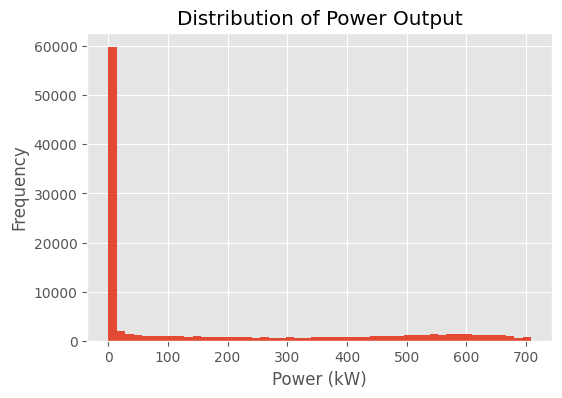

In [41]:
plt.figure(figsize=(6,4))
df_combined_full["ac_output_kw"].hist(bins=50)
plt.title("Distribution of Power Output")
plt.xlabel("Power (kW)")
plt.ylabel("Frequency")
plt.show()

The Distribution of Power Output histogram shows that most observations occur near zero power, which corresponds primarily to nighttime periods when solar panels do not generate electricity. The large concentration near zero is also influenced by the data gap visible in the time-series plot between early 2022 and mid-2022, where power values appear to drop to zero. As power increases, the distribution spreads across higher values up to about 700 kW, representing normal daytime solar production levels.

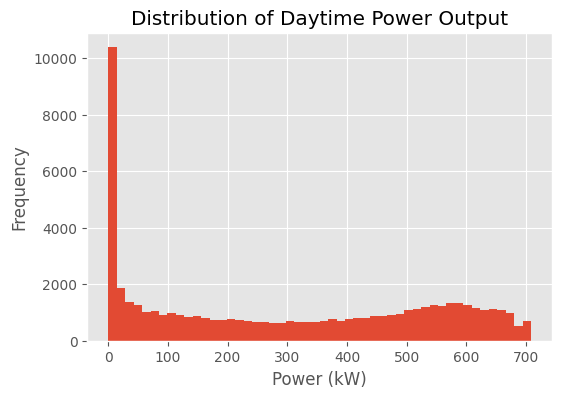

In [42]:
plt.figure(figsize=(6,4))
df_combined_full_daytime["ac_output_kw"].hist(bins=50)
plt.title("Distribution of Daytime Power Output")
plt.xlabel("Power (kW)")
plt.ylabel("Frequency")
plt.show()

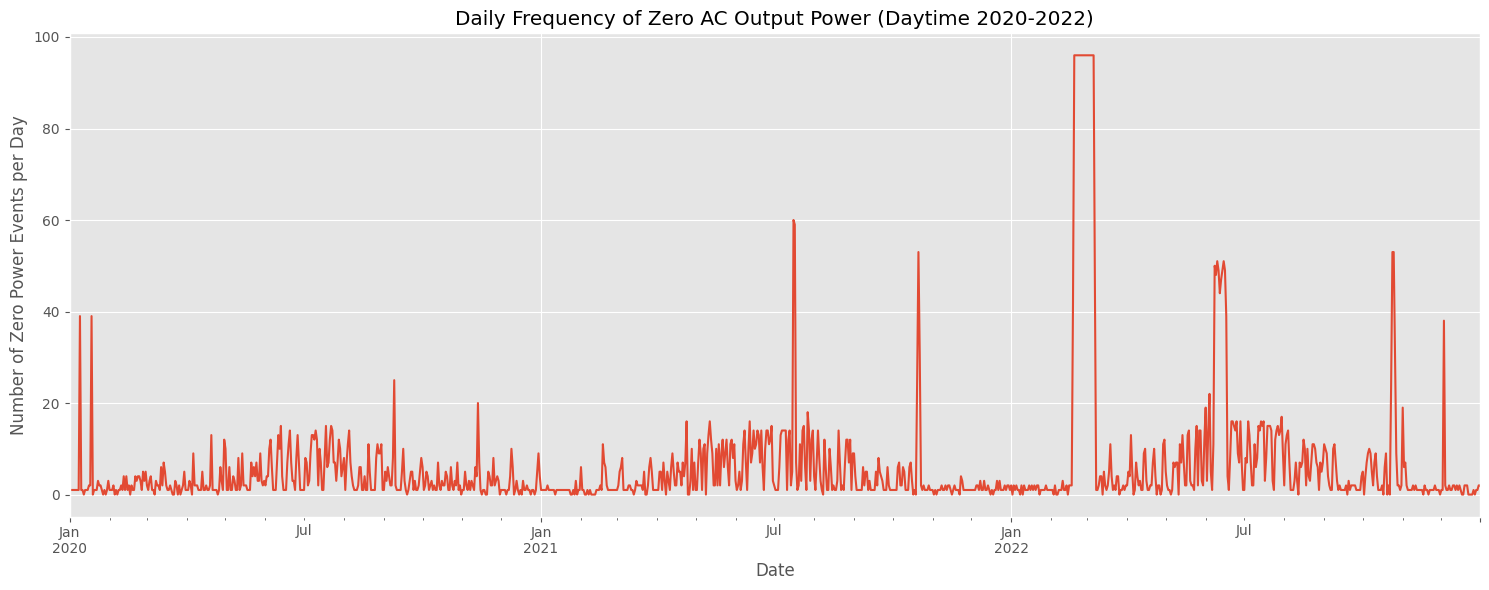

Total zero AC output power events during daytime (2020-2022): 6732 at 15-minute intervals.
Maximum daily zero power events: 96 (This means up to 24.0 hours of zero power on a single day).


In [43]:
# Filter for the years 2020-2022 as requested by the user
df_filtered_years = df_combined_full_daytime.loc['2020-01-01':'2022-12-31']

# Identify periods where AC output power is zero
zero_power_events = (df_filtered_years['ac_output_kw'] == 0).astype(int)

# Resample to daily frequency (sum of zero events per day)
daily_zero_power_frequency = zero_power_events.resample('D').sum()

plt.figure(figsize=(15, 6))
daily_zero_power_frequency.plot(kind='line')
plt.title("Daily Frequency of Zero AC Output Power (Daytime 2020-2022)")
plt.xlabel("Date")
plt.ylabel("Number of Zero Power Events per Day")
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Total zero AC output power events during daytime (2020-2022): {zero_power_events.sum()} at 15-minute intervals.")
print(f"Maximum daily zero power events: {daily_zero_power_frequency.max()} (This means up to {daily_zero_power_frequency.max() * 15 / 60} hours of zero power on a single day).")

The Daily Frequency of Zero AC Output Power plot shows how often the solar system recorded zero power events during daytime between 2020 and 2022. Most days have only a few such events, but occasional spikes indicate periods where the system repeatedly produced no power, which may suggest cloud cover, temporary system faults, sensor issues, or maintenance periods.

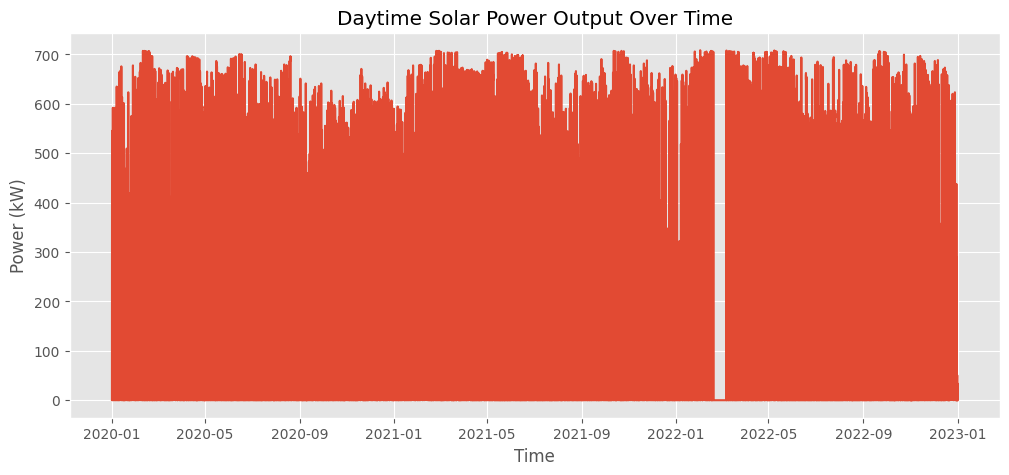

In [44]:
plt.figure(figsize=(12,5))
plt.plot(df_combined_full_daytime.index, df_combined_full_daytime["ac_output_kw"])
plt.title("Daytime Solar Power Output Over Time")
plt.xlabel("Time")
plt.ylabel("Power (kW)")
plt.show()

The Daytime Solar Power Output Over Time plot shows the system’s power generation during daylight hours, with output typically ranging between about 500–720 kW under normal operating conditions. Compared to the earlier Solar Power Output Over Time plot that included nighttime periods, this view removes the regular zero-power values from night, making the **data gap between early 2022 and mid-2022—where power drops to zero—much more noticeable as a likely missing data or system outage period.

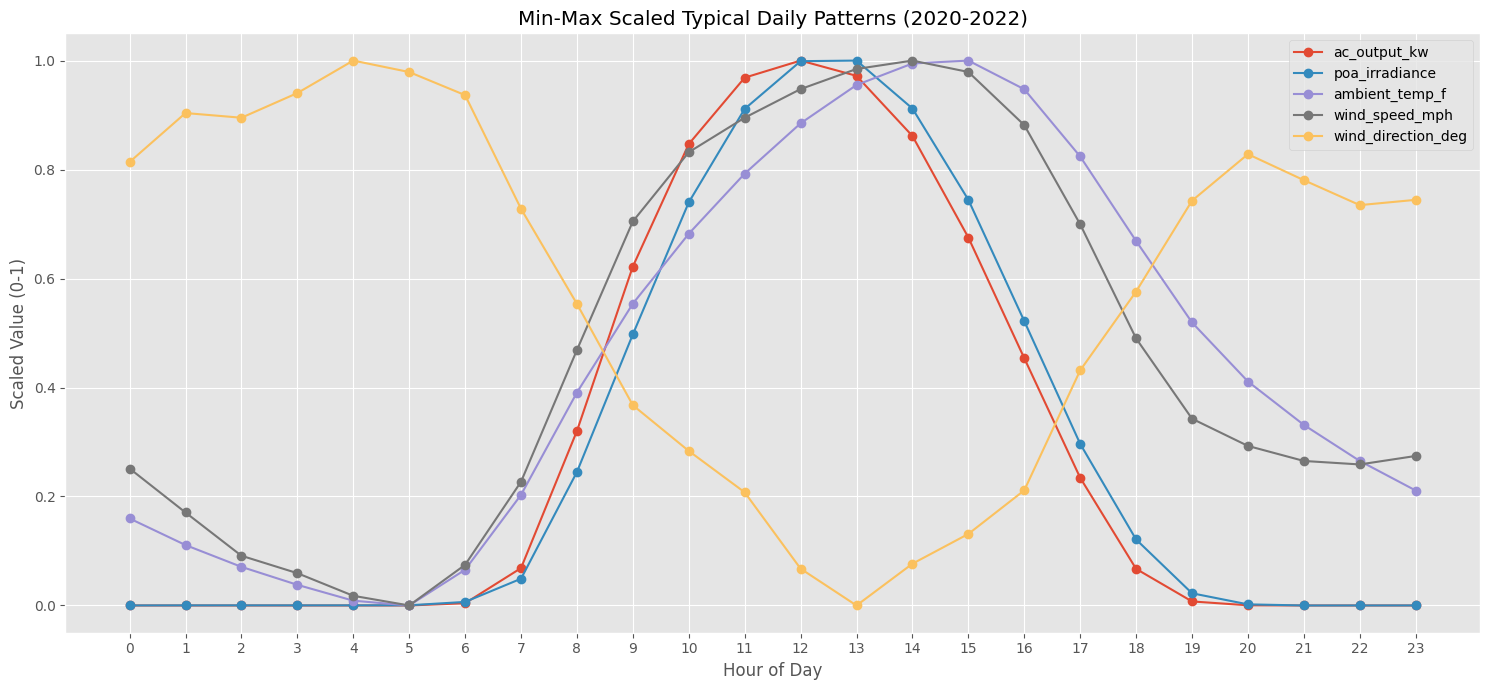

In [45]:
# Select the features for daily pattern analysis
features_for_daily_pattern = [
    'ac_output_kw',
    'poa_irradiance',
    'ambient_temp_f',
    'wind_speed_mph',
    'wind_direction_deg'
]

df_daily_patterns = df_combined_full[features_for_daily_pattern].copy()

# Extract hour from the index
df_daily_patterns['hour'] = df_daily_patterns.index.hour

# Calculate the mean for each feature for each hour of the day
hourly_averages = df_daily_patterns.groupby('hour')[features_for_daily_pattern].mean()

# Scale the hourly averages using MinMaxScaler
scaler = MinMaxScaler()
hourly_averages_scaled = scaler.fit_transform(hourly_averages)

# Convert back to DataFrame for easier plotting, keeping original column names and hour index
hourly_averages_scaled_df = pd.DataFrame(
    hourly_averages_scaled,
    columns=features_for_daily_pattern,
    index=hourly_averages.index
)

# Plot the scaled daily patterns
plt.figure(figsize=(15, 7))
for column in hourly_averages_scaled_df.columns:
    plt.plot(hourly_averages_scaled_df.index, hourly_averages_scaled_df[column], marker='o', label=column)

plt.title('Min-Max Scaled Typical Daily Patterns (2020-2022)')
plt.xlabel('Hour of Day')
plt.ylabel('Scaled Value (0-1)')
plt.xticks(range(0, 24)) # Ensure all hours are displayed
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

The Min-Max Scaled Typical Daily Patterns plot shows how different environmental variables and solar power output change throughout a typical day. Both POA irradiance and AC power output rise in the morning, peak around midday, and decline toward evening, reflecting the daily solar production cycle. Other variables such as ambient temperature and wind speed follow smoother daily patterns, while wind direction varies more independently across the day.

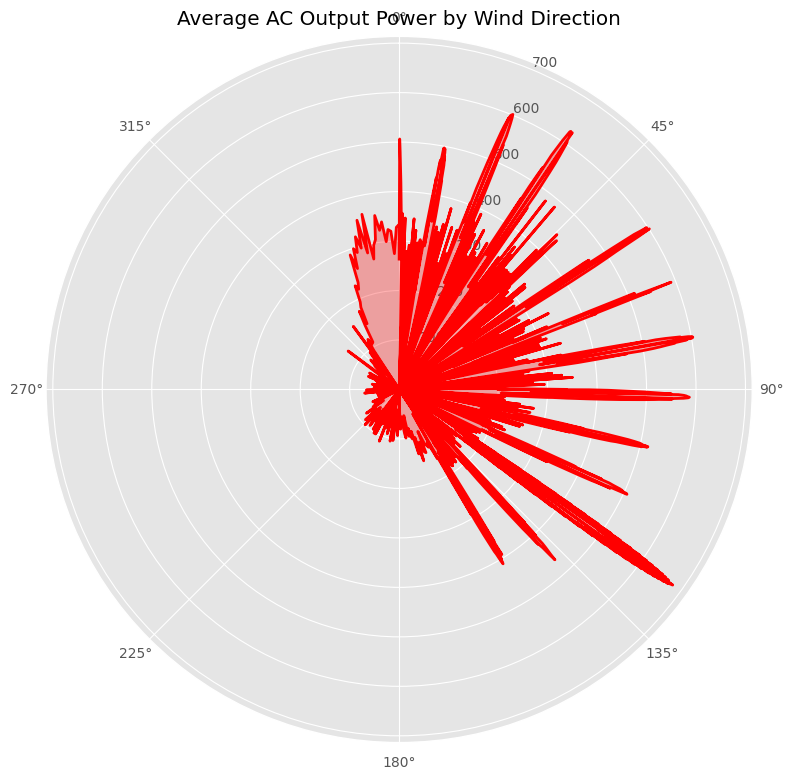

Interpretation: The plot shows the average AC output power (radial distance) for each wind direction (angle).
Areas where the red fill extends further from the center indicate higher average power output from winds blowing in that direction.


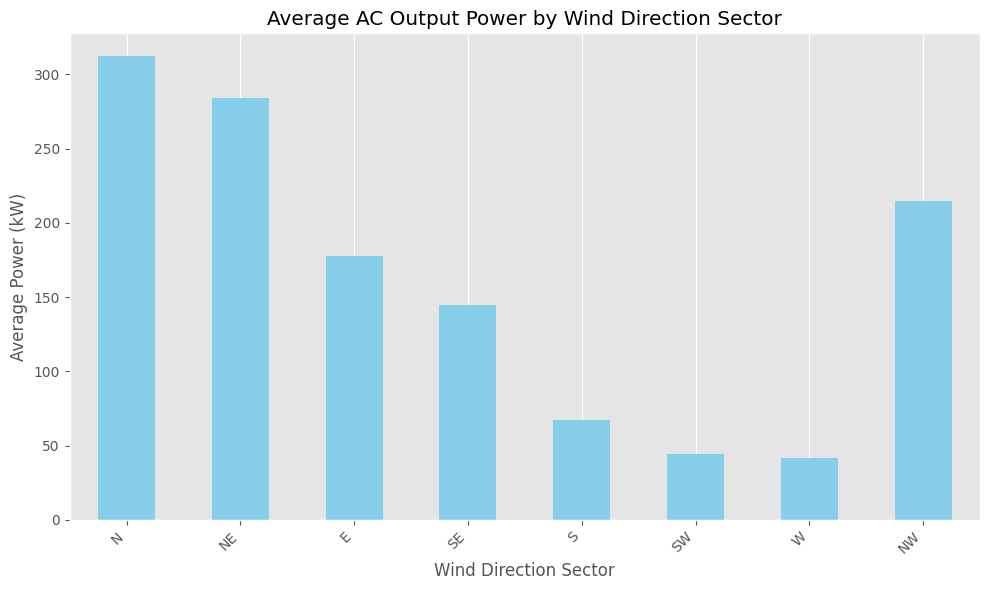

In [46]:
# Group by wind direction and calculate mean ac_output_kw
# We'll use the original df_combined_full for this to include all data points if 'daytime' filtering is not desired for wind analysis
# If only daytime is relevant, use df_combined_full_daytime

# Let's use df_combined_full for a broader view of wind direction's impact
wind_power_data = df_combined_full.groupby('wind_direction_deg')['ac_output_kw'].mean().reset_index()

# Convert degrees to radians for the polar plot
theta = np.deg2rad(wind_power_data['wind_direction_deg'])
radii = wind_power_data['ac_output_kw']

plt.figure(figsize=(8, 8))
ax = plt.subplot(111, projection='polar')
ax.plot(theta, radii, color='r', linewidth=2)
ax.fill(theta, radii, color='r', alpha=0.3)
ax.set_theta_zero_location("N") # Set 0 degrees to North
ax.set_theta_direction(-1) # Clockwise direction

ax.set_title('Average AC Output Power by Wind Direction', va='bottom')
plt.tight_layout()
plt.show()

print("Interpretation: The plot shows the average AC output power (radial distance) for each wind direction (angle).")
print("Areas where the red fill extends further from the center indicate higher average power output from winds blowing in that direction.")

# Alternative: Binning wind directions and using a bar plot
# Define bins for wind direction (e.g., 8 cardinal directions)
bins = np.arange(0, 361, 45) # 0-45, 45-90, ..., 315-360
labels = ['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW', 'N'] # The last 'N' wraps around

# Create a categorical column for wind direction bins
df_combined_full['wind_direction_bin'] = pd.cut(
    df_combined_full['wind_direction_deg'], bins=bins, labels=labels[:-1], right=False, ordered=False
)

# Calculate mean power for each bin, addressing the FutureWarning with observed=False
mean_power_by_bin = df_combined_full.groupby('wind_direction_bin', observed=False)['ac_output_kw'].mean().reindex(labels[:-1])

plt.figure(figsize=(10, 6))
mean_power_by_bin.plot(kind='bar', color='skyblue')
plt.title('Average AC Output Power by Wind Direction Sector')
plt.xlabel('Wind Direction Sector')
plt.ylabel('Average Power (kW)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
plt.tight_layout()
plt.show()


The two plots illustrate the relationship between wind direction and average AC output power. The polar plot visually maps average power to specific wind directions, while the bar chart groups these directions into cardinal sectors, making it easy to see which wind directions are associated with higher or lower power generation.



---

